# 15 — Visualise Workload-Flexibility Results

## Research purpose

Examine the magnitude, constraints, geography and historical weather variation of workload shifting under six and nine candidate hours. Compare the completed Optimised LP allocations with Greedy.


## Imports

Load the libraries used to read and validate the completed workload results and draw the comparison figures.


In [1]:
from pathlib import Path
import hashlib
import json

import geopandas as gpd
import pyarrow.parquet as pq
import requests
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display

## Project paths

Locate the project root and define the paths for the workload summaries, completed allocations, map boundaries and saved figures. Keep the six-hour and nine-hour inputs separate and define three comparison tables.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    
if not (PROJECT_ROOT / "notebooks").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise RuntimeError("Launch Jupyter from the folder containing data/ and notebooks/, or from its notebooks/ directory.")

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_FINAL = PROJECT_ROOT / "data" / "final"
VIS_ROOT = PROJECT_ROOT / "visualizations" / "flexibility"
SUMMARY_ROOTS = {
    6: DATA_FINAL / "candidate_hours_6h",
    9: DATA_FINAL / "candidate_hours_9h",
}
DETAIL_ROOTS = {
    (6, "daily_spatiotemporal"): DATA_INTERIM / "operator_daily_spatiotemporal_shift_allocations_6h_by_scenario_parquet",
    (9, "daily_spatiotemporal"): DATA_INTERIM / "operator_daily_spatiotemporal_shift_allocations_9h_by_scenario_parquet",
    (6, "same_hour_geographic"): DATA_INTERIM / "operator_same_hour_geographic_shift_allocations_6h_by_scenario_parquet",
    (9, "same_hour_geographic"): DATA_INTERIM / "operator_same_hour_geographic_shift_allocations_9h_by_scenario_parquet",
}

NATURAL_EARTH_ZIP = PROJECT_ROOT / "data" / "raw" / "maps" / "ne_110m_admin_0_countries.zip"
LOCATION_COMPARISON_PATH = DATA_FINAL / "workload_current_vs_planned_comparison.csv"
METHOD_COMPARISON_PATH = DATA_FINAL / "workload_allocation_method_comparison.csv"
WEATHER_COMPARISON_PATH = DATA_FINAL / "workload_annual_weather_sensitivity.csv"

## Comparison settings

Use 85% utilisation and 25% flexibility as the reference for both candidate-hour settings and the weather years 2023–2025. Treat Optimised LP as the primary technical-potential method and Greedy as the comparison, with consistent colours and labels throughout.


In [3]:
NATURAL_EARTH_URL = "https://naturalearth.s3.amazonaws.com/5.1.2/110m_cultural/ne_110m_admin_0_countries.zip"
NATURAL_EARTH_SHA256 = "0f243aeac8ac6cf26f0417285b0bd33ac47f1b5bdb719fd3e0df37d03ea37110"
COLORS = {'Amazon': '#ff9900', 'Google': '#4285f4', 'Microsoft': '#7fba00', 'send': '#c44e52', 'receive': '#4c72b0', 'neutral': '#8a8f98', 'greedy': '#b8bec5', 'optimised_lp': '#527e9e'}
CANDIDATE_HOURS = (6, 9)
ALLOCATION_METHODS = ("greedy", "optimised_lp")
METHOD_TITLES = {"greedy": "Greedy - comparison", "optimised_lp": "Optimised LP  primary technical potential"}
REFERENCE_UTILISATION_ID = "util_85"
REFERENCE_FLEXIBILITY_ID = "flex_25"
layers = ["current_only", "current_plus_future"]
operators = ["Amazon", "Google", "Microsoft"]
modes = ["daily_spatiotemporal", "same_hour_geographic"]
weather_years = [2023, 2024, 2025]
mode_labels = {"same_hour_geographic": "Same-hour geographic", "daily_spatiotemporal": "Daily spatio-temporal"}
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 220, "font.size": 10, "axes.titlesize": 13,
                     "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
                     "legend.fontsize": 9, "axes.spines.top": False, "axes.spines.right": False})

## Input validation functions

Define checks for allocation identities, checksums and row counts. Check that summary tables contain every expected scenario combination and finite values.


In [4]:
def validate_detail(path, *, allocation_method, shift_mode, candidate_hours, utilisation_id, flexibility_id):
    path = Path(path)
    marker = path.parent / "_SUCCESS.json"
    if not path.is_file() or not marker.is_file():
        raise FileNotFoundError(f"A supplied completed allocation partition and its _SUCCESS.json are required: {path}")
    status = json.loads(marker.read_text())
    expected = dict(allocation_method=allocation_method, shift_mode=shift_mode,
                    utilisation_scenario_id=utilisation_id, flexibility_scenario_id=flexibility_id)
    for field, value in expected.items():
        if status.get(field) != value:
            raise ValueError(f"{marker}: {field} does not match {value!r}")
    if int(status.get("candidate_hours", 6)) != candidate_hours:
        raise ValueError(f"{marker}: candidate-hour identity does not match the selected input")

## Load workload summaries

Load the five workload summary families, query locations, load profiles and renewable rankings, then verify the six completed reference partitions. Use the supplied Natural Earth archive when available and verify its checksum before reading the boundaries.

In [5]:
summary_filenames = {
    "daily_shift": "geographic_workload_shifting_daily_summary.csv",
    "shift_mode_operator_year": "shift_mode_comparison_operator_year_summary.csv",
    "shift_mode_total": "shift_mode_comparison_total_summary.csv",
    "scenario_operator_year": "shift_mode_flexibility_scenario_comparison_operator_year_summary.csv",
}

summaries = {}
for name, filename in summary_filenames.items():
    parts = []
    for hours, root in SUMMARY_ROOTS.items():
        path = root / filename
        if not path.is_file():
            raise FileNotFoundError(f"Required supplied {hours}h workload summary is missing: {path}")
        frame = pd.read_csv(path)
        if "candidate_hours" in frame and not frame["candidate_hours"].eq(hours).all():
            raise ValueError(f"Candidate-hour values disagree with the selected source: {path}")
        frame["candidate_hours"] = hours
        parts.append(frame)
    summaries[name] = pd.concat(parts, ignore_index=True)

### Load supporting location and profile data


In [6]:
query_locations = pd.read_csv(DATA_INTERIM / "renewables_ninja_query_locations.csv")
load_profiles = pd.read_csv(DATA_INTERIM / "datacenter_generic_load_shape_profiles.csv")
daily_flex = pd.read_csv(DATA_INTERIM / "cluster_operator_daily_flexibility_summary.csv")
ranked_hourly = pd.read_parquet(DATA_INTERIM / "renewable_availability_cluster_ranked_hourly.parquet",
    columns=["query_location_id", "weather_year", "utc_date", "utc_hour", "solar_capacity_factor",
             "wind_capacity_factor", "renewable_availability_index", "receive_rank_daily", "send_rank_daily",
             "receive_candidate", "send_candidate"])
ranked_hourly["utc_date_key"] = pd.to_datetime(ranked_hourly["utc_date"]).dt.strftime("%Y-%m-%d")
daily_flex["utc_date_key"] = pd.to_datetime(daily_flex["utc_date"]).dt.strftime("%Y-%m-%d")

### Prepare map coordinates and load map boundaries

In [7]:
coords = query_locations[["query_location_id", "representative_lat", "representative_lon"]].copy()
if coords["query_location_id"].duplicated().any() or not np.isfinite(coords[["representative_lat", "representative_lon"]]).all().all():
    raise ValueError("Query coordinates must be finite and unique by query_location_id")

# Use the pinned archive, acquiring it only when absent.
world_supplied = NATURAL_EARTH_ZIP.exists()
if world_supplied:
    world_content = NATURAL_EARTH_ZIP.read_bytes()
else:
    response = requests.get(NATURAL_EARTH_URL, timeout=60)
    response.raise_for_status()
    world_content = response.content
if hashlib.sha256(world_content).hexdigest() != NATURAL_EARTH_SHA256:
    raise ValueError(f"Natural Earth archive does not match the pinned source: {NATURAL_EARTH_ZIP}")
if not world_supplied:
    NATURAL_EARTH_ZIP.parent.mkdir(parents=True, exist_ok=True)
    NATURAL_EARTH_ZIP.write_bytes(world_content)
world = gpd.read_file(f"zip://{NATURAL_EARTH_ZIP}").to_crs("EPSG:4326")

### Locate completed allocations


In [8]:
partition_paths = {}
for (hours, mode), root in DETAIL_ROOTS.items():
    for method in ALLOCATION_METHODS:
        if mode == "same_hour_geographic" and method == "greedy":
            continue  # Only LP maps use same-hour allocation details.
        path = (root / f"method_{method}" / f"util_{REFERENCE_UTILISATION_ID}"
                / f"flex_{REFERENCE_FLEXIBILITY_ID}" / "part-00000.parquet")
        partition_paths[(hours, method, mode)] = path
        validate_detail(path,
            allocation_method=method, shift_mode=mode, candidate_hours=hours,
            utilisation_id=REFERENCE_UTILISATION_ID, flexibility_id=REFERENCE_FLEXIBILITY_ID)

## Shared plotting variables

Select the daily shifting summary and define the energy metrics and grouping keys used in the comparisons below.

In [9]:
daily_shift = summaries["daily_shift"]
energy_metrics = ["shifted_mwh", "total_weighted_renewable_gain", "total_weighted_abs_time_hours"]
reference_keys = ["candidate_hours", "allocation_method", "model_layer", "shift_mode"]

## Figure saving and axis limits

Define functions to save and display each figure and calculate axis limits from the plotted values.


In [10]:
# Display, save and close only the figure supplied by the current cell.
def save_figure(fig, stem, output_group):
    output_dir = VIS_ROOT / output_group
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f"{stem}.png", bbox_inches="tight")
    display(fig)
    plt.close(fig)

# Calculate a padded upper axis limit, using a fallback when no positive finite values are available.
def upper_axis(values, padding=0.12, floor=1.0):
    numeric = pd.to_numeric(pd.Series(values), errors="coerce")
    maximum = numeric.replace([np.inf, -np.inf], np.nan).max()
    return floor if pd.isna(maximum) or maximum <= 0 else float(maximum) * (1 + padding)

## 1 — Query-location map

Map the representative query locations. These points represent grouped inventory locations used for renewable profiles. They are not generation sites.


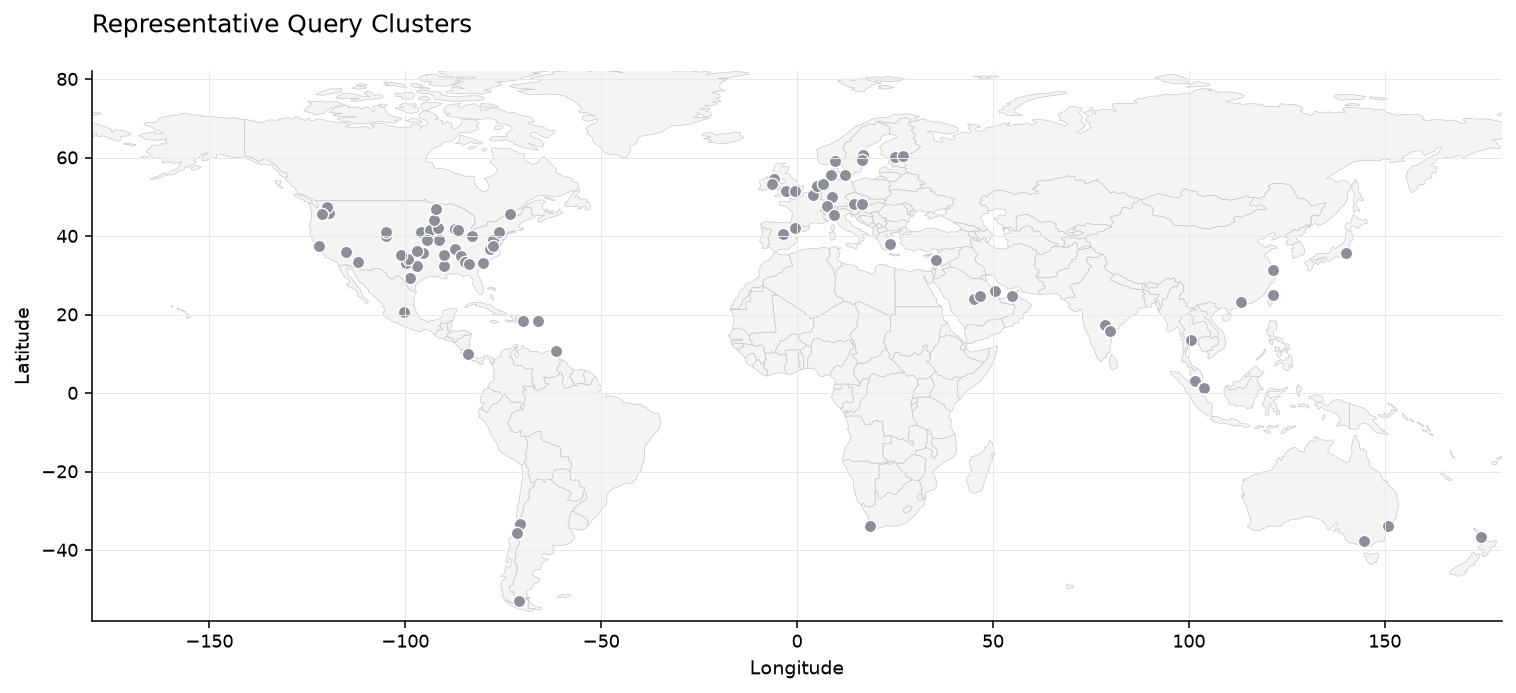

In [11]:
# representative query-location map
query_map_fig, query_map_ax = plt.subplots(figsize=(13, 7))
world.plot(ax=query_map_ax, color="#f4f4f2", edgecolor="#c6c6c6", linewidth=0.35)
query_map_ax.set(xlim=(-180, 180), ylim=(-58, 82), xlabel="Longitude", ylabel="Latitude")
query_map_ax.grid(True, color="#e8e8e8", linewidth=0.5)
query_map_points = query_locations.copy()
query_map_size = 40  # Equal marker area in points squared for every query location.
query_map_ax.scatter(
    query_map_points["representative_lon"],
    query_map_points["representative_lat"],
    s=query_map_size,
    color="#8a8f98",
    alpha=1.0,
    edgecolor="white",
    linewidth=0.7,
)
query_map_ax.set_title("Representative Query Clusters", loc="left", pad=20)

save_figure(query_map_fig, "01_query_cluster_capacity_map", "common")

## 2 — Daily renewable-ranking example

Select Amazon's Ashburn query location and use 5 September 2025 UTC to illustrate the daily ranking. Plot the solar, wind and 50/50 renewable-index profiles and mark the sending and receiving candidates for both hour settings. This selected day illustrates candidate selection rather than an allocation result.


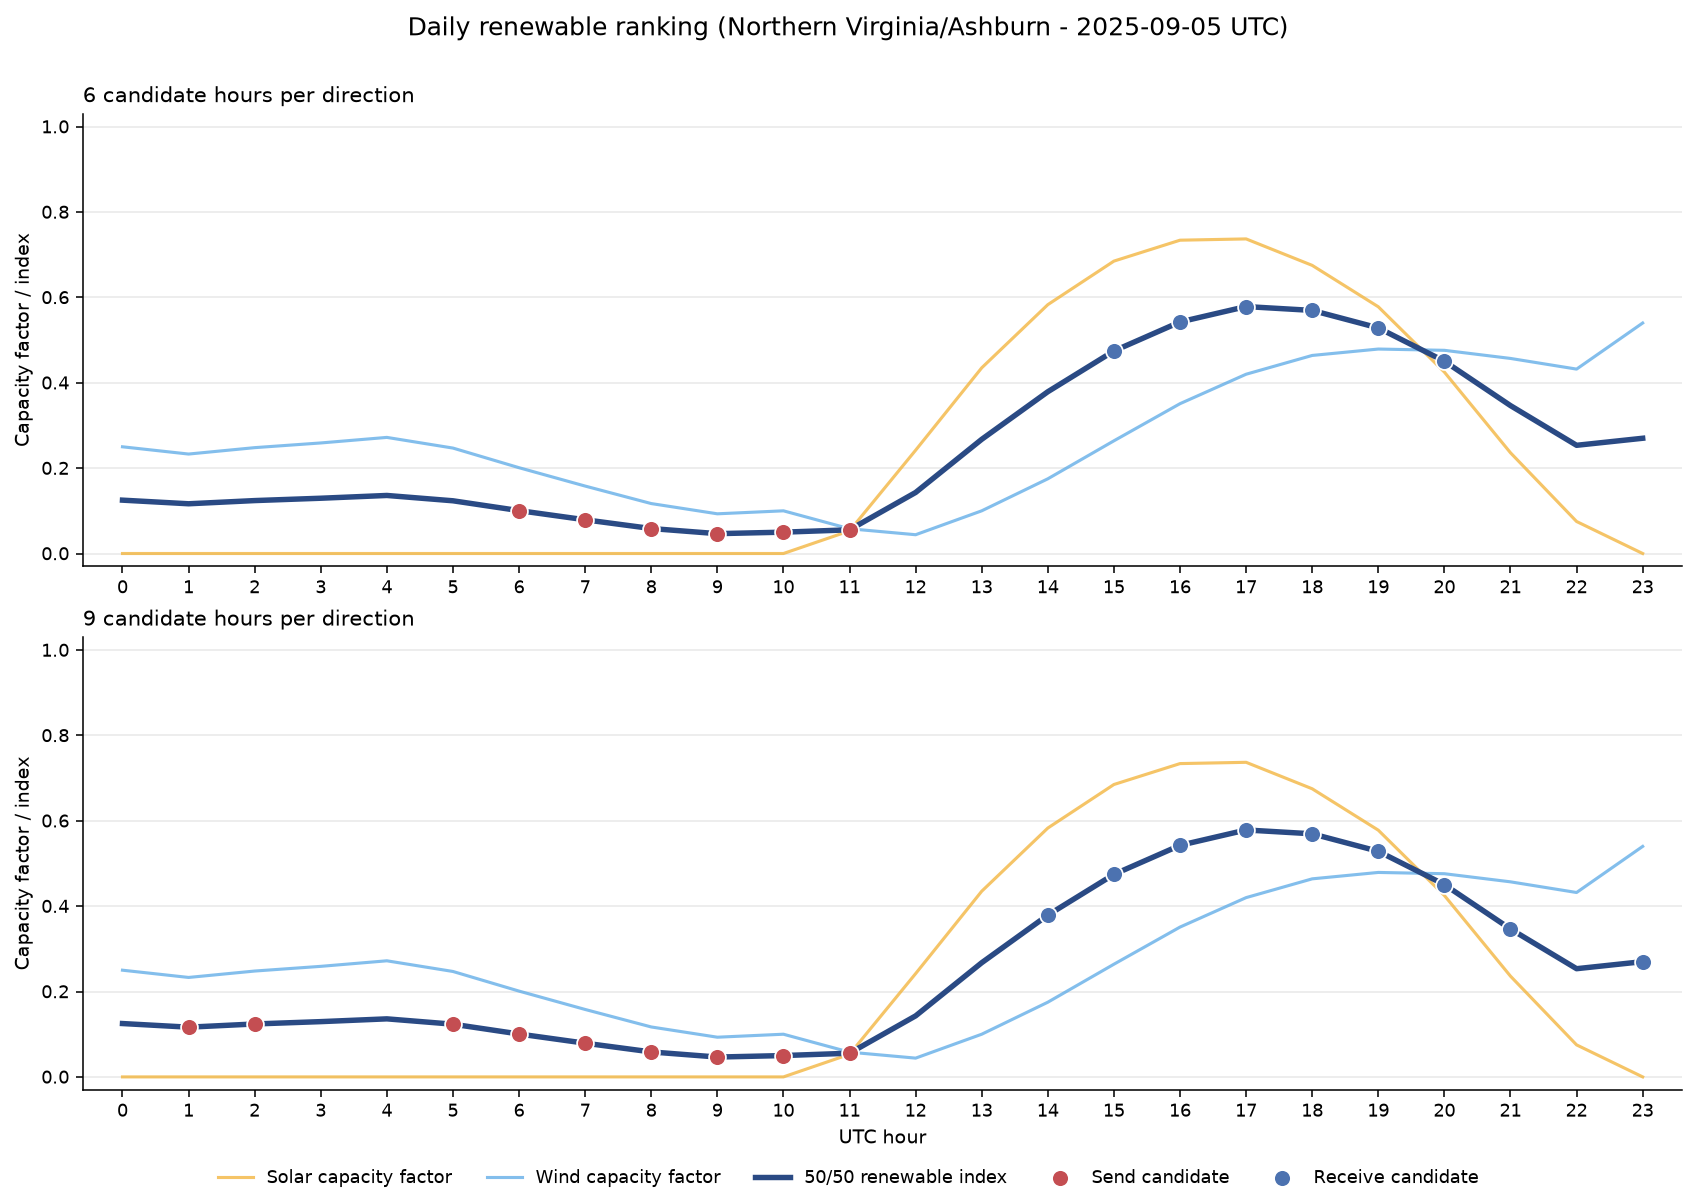

In [12]:
selected_date = "2025-09-05"

campus_members = query_locations["campus_refs"].fillna("").str.split("|")
ashburn_query_id = query_locations.loc[
    query_locations["country_code"].eq("USA")
    & query_locations["timezone"].eq("America/New_York")
    & campus_members.map(lambda members: "CAMPUS-00047" in members),
    "query_location_id",
].iloc[0]

rank_day = ranked_hourly.loc[
    ranked_hourly["query_location_id"].eq(ashburn_query_id)
    & ranked_hourly["utc_date_key"].eq(selected_date)
].sort_values("utc_hour")

x = rank_day["utc_hour"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True, sharey=True, layout="constrained")

for hours, ax in zip(CANDIDATE_HOURS, axes):
    for column, label, color, width, alpha, zorder in [
        ("solar_capacity_factor", "Solar capacity factor", "#f2b134", 1.6, 0.75, 2),
        ("wind_capacity_factor", "Wind capacity factor", "#5aa9e6", 1.6, 0.75, 2),
        ("renewable_availability_index", "50/50 renewable index", "#2a4a84", 2.8, None, 3),
    ]:
        ax.plot(x, rank_day[column], label=label, color=color,linewidth=width, alpha=alpha, zorder=zorder)

    for side in ("send", "receive"):
        eligible = rank_day[f"{side}_rank_daily"].le(hours)
        ax.scatter(
            x.loc[eligible], rank_day.loc[eligible, "renewable_availability_index"],
            label=f"{side.title()} candidate", color=COLORS[side],
            s=75, edgecolors="white", linewidths=0.9, zorder=4,
        )

    ax.set_title(f"{hours} candidate hours per direction", loc="left", fontsize=11)
    ax.set(ylabel="Capacity factor / index", xlim=(-0.6, 23.6), ylim=(-0.03, 1.03), xticks=range(24), yticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="x", labelbottom=True, labelsize=9)
    ax.grid(axis="y", color="#e8e8e8", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("UTC hour")

fig.legend( *axes[0].get_legend_handles_labels(), loc="outside lower center", ncols=5, frameon=False, fontsize=9)
fig.suptitle(f"Daily renewable ranking (Northern Virginia/Ashburn - {selected_date} UTC)\n", fontsize=13)

save_figure(fig, "02_daily_renewable_ranking", "common")

## 3 — Normalised load profile

Average the monthly UKPN profiles to plot weekday and weekend load shapes by local hour. This generic demand-shape proxy is applied to each model node using its IANA local clock.


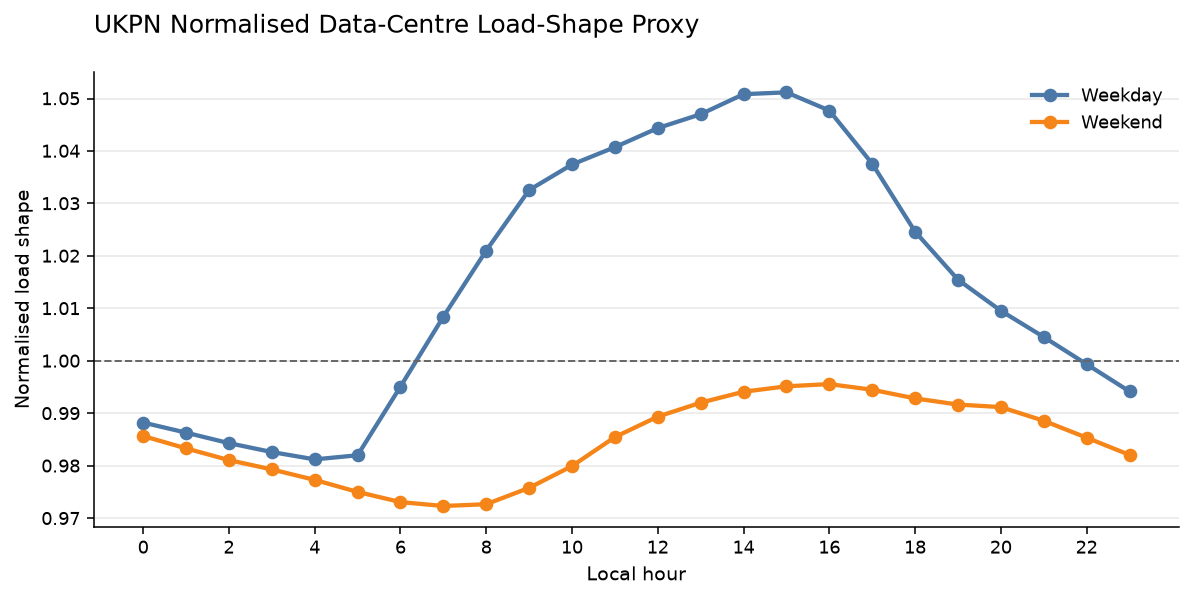

In [13]:
# UKPN normalized load-shape profile in the profile's local clock
load_shape_required_profile_columns = {
    "profile_variant",
    "profile_timezone",
    "profile_month",
    "profile_day_type",
    "profile_hour",
    "normalized_load_shape",
}

load_shape_missing_profile_columns = sorted(load_shape_required_profile_columns - set(load_profiles.columns))

load_shape_profile = load_profiles.loc[load_profiles["profile_variant"].eq("all_clean_sites")].copy()
load_shape_profile_mean = (
    load_shape_profile.groupby(["profile_day_type", "profile_hour"], as_index=False)
    ["normalized_load_shape"]
    .mean()
)

load_shape_fig, load_shape_ax = plt.subplots(figsize=(10, 5))
for load_shape_day_type, load_shape_color in [("weekday", "#4c78a8"), ("weekend", "#f58518")]:
    load_shape_data = load_shape_profile_mean.loc[load_shape_profile_mean["profile_day_type"].eq(load_shape_day_type)]
    load_shape_ax.plot(
        load_shape_data["profile_hour"],
        load_shape_data["normalized_load_shape"],
        marker="o",
        linewidth=2.2,
        label=load_shape_day_type.title(),
        color=load_shape_color,
    )

load_shape_ax.axhline(1.0, color="#666", linewidth=1, linestyle="--")
load_shape_ax.set_xticks(range(0, 24, 2))
load_shape_ax.set_xlabel("Local hour")
load_shape_ax.set_ylabel("Normalised load shape")
load_shape_ax.set_title("UKPN Normalised Data-Centre Load-Shape Proxy", loc="left", pad=20)
load_shape_fig.subplots_adjust(bottom=0.23)
load_shape_ax.legend(frameon=False)
load_shape_ax.grid(True, axis="y", color="#e8e8e8")

save_figure(load_shape_fig, "03_normalised_load_profile", "common")

## 4 — Annual network comparisons

Sum the separate operator allocations within each weather year and average the three annual network totals. Calculate renewable-index gain by dividing the summed weighted gain by shifted MWh, keeping each method, location scenario, shifting mode and candidate-hour setting separate.


In [14]:
operator_year_all = summaries["shift_mode_operator_year"]

network_annual = operator_year_all.groupby(reference_keys + ["weather_year"], as_index=False)[energy_metrics].sum()
network_annual["shifted_gwh"] = network_annual["shifted_mwh"] / 1000
network_mean = network_annual.groupby(reference_keys, as_index=False).agg(
    mean_annual_shifted_gwh=("shifted_gwh", "mean"),
    shifted_mwh=("shifted_mwh", "sum"),
    total_weighted_renewable_gain=("total_weighted_renewable_gain", "sum"))
network_mean["weighted_renewable_index_gain"] = network_mean["total_weighted_renewable_gain"].div(
    network_mean["shifted_mwh"].where(network_mean["shifted_mwh"].ne(0)))

comparison_index = pd.MultiIndex.from_product([CANDIDATE_HOURS, modes], names=["candidate_hours", "shift_mode"])

### Current and planned locations

Compare LP results for current locations and current plus planned locations at 85% utilisation and 25% flexibility. Express the difference relative to the current-only result and export the unrounded comparison.


In [15]:
location_comparison = network_mean.loc[network_mean["allocation_method"].eq("optimised_lp")].pivot(
    index=["candidate_hours", "shift_mode"], columns="model_layer", values="mean_annual_shifted_gwh").reindex(comparison_index)
location_comparison = location_comparison.rename(columns={"current_only": "current_only_mean_annual_shifted_gwh",
    "current_plus_future": "current_plus_planned_mean_annual_shifted_gwh"})
location_comparison["difference_mean_annual_gwh"] = location_comparison["current_plus_planned_mean_annual_shifted_gwh"] - location_comparison["current_only_mean_annual_shifted_gwh"]
location_comparison["difference_percent_of_current_only"] = 100 * location_comparison["difference_mean_annual_gwh"].div(
    location_comparison["current_only_mean_annual_shifted_gwh"].where(location_comparison["current_only_mean_annual_shifted_gwh"].ne(0)))
location_comparison = location_comparison.reset_index().rename_axis(columns=None)
location_comparison.to_csv(LOCATION_COMPARISON_PATH, index=False)

display(location_comparison.rename(columns={"candidate_hours": "Candidate hours", "shift_mode": "Shifting mode",
    "current_only_mean_annual_shifted_gwh": "Current only (GWh/year)",
    "current_plus_planned_mean_annual_shifted_gwh": "Current plus planned (GWh/year)",
    "difference_mean_annual_gwh": "Difference (GWh/year)",
    "difference_percent_of_current_only": "Difference / Current only (%)"})
    .replace({"Shifting mode": mode_labels}).style.hide(axis="index").format(precision=2, na_rep="Undefined"))

Candidate hours,Shifting mode,Current only (GWh/year),Current plus planned (GWh/year),Difference (GWh/year),Difference / Current only (%)
6,Daily spatio-temporal,3347.45,4178.17,830.72,24.82
6,Same-hour geographic,1836.72,2523.22,686.50,37.38
9,Daily spatio-temporal,5204.37,6495.33,1290.96,24.81
9,Same-hour geographic,3419.86,4593.24,1173.38,34.31


### Allocation methods and renewable-index gains

Compare Greedy and LP for current plus planned locations at the reference workload assumptions, expressing percentage differences relative to Greedy. Include MWh-weighted renewable-index gains and each method's same-hour share of daily shifted energy, then export the unrounded table.


In [16]:
reference_mean = network_mean.loc[network_mean["model_layer"].eq("current_plus_future")]

method_comparison = pd.DataFrame(index=comparison_index)
for method in ALLOCATION_METHODS:
    values = reference_mean.loc[reference_mean["allocation_method"].eq(method)].set_index(["candidate_hours", "shift_mode"])
    method_comparison[f"{method}_mean_annual_shifted_gwh"] = values["mean_annual_shifted_gwh"]
    method_comparison[f"{method}_weighted_renewable_index_gain"] = values["weighted_renewable_index_gain"]
    mode_energy = values["shifted_mwh"].unstack("shift_mode")
    share = mode_energy["same_hour_geographic"].div(mode_energy["daily_spatiotemporal"].where(mode_energy["daily_spatiotemporal"].ne(0)))
    method_comparison[f"{method}_same_hour_share_of_daily"] = method_comparison.index.get_level_values("candidate_hours").map(share)
method_comparison["lp_minus_greedy_mean_annual_gwh"] = method_comparison["optimised_lp_mean_annual_shifted_gwh"] - method_comparison["greedy_mean_annual_shifted_gwh"]
method_comparison["lp_minus_greedy_percent_of_greedy"] = 100 * method_comparison["lp_minus_greedy_mean_annual_gwh"].div(
    method_comparison["greedy_mean_annual_shifted_gwh"].where(method_comparison["greedy_mean_annual_shifted_gwh"].ne(0)))
method_comparison = method_comparison.reset_index()
method_comparison.to_csv(METHOD_COMPARISON_PATH, index=False)

# Split only the display into two narrow blocks; one CSV retains every unrounded value.
display(method_comparison[["candidate_hours", "shift_mode", "greedy_mean_annual_shifted_gwh", "optimised_lp_mean_annual_shifted_gwh",
    "lp_minus_greedy_mean_annual_gwh", "lp_minus_greedy_percent_of_greedy"]].rename(columns={
    "candidate_hours": "Candidate hours", "shift_mode": "Shifting mode", "greedy_mean_annual_shifted_gwh": "Greedy (GWh/year)",
    "optimised_lp_mean_annual_shifted_gwh": "LP (GWh/year)", "lp_minus_greedy_mean_annual_gwh": "LP − Greedy (GWh/year)",
    "lp_minus_greedy_percent_of_greedy": "LP − Greedy / Greedy (%)"}).replace({"Shifting mode": mode_labels})
    .style.hide(axis="index").format(precision=3, na_rep="Undefined"))

display(method_comparison[["candidate_hours", "shift_mode", "greedy_weighted_renewable_index_gain", "optimised_lp_weighted_renewable_index_gain",
    "greedy_same_hour_share_of_daily", "optimised_lp_same_hour_share_of_daily"]].rename(columns={
    "candidate_hours": "Candidate hours", "shift_mode": "Shifting mode", "greedy_weighted_renewable_index_gain": "Greedy weighted index gain",
    "optimised_lp_weighted_renewable_index_gain": "LP weighted index gain", "greedy_same_hour_share_of_daily": "Greedy same-hour/daily share",
    "optimised_lp_same_hour_share_of_daily": "LP same-hour/daily share"}).replace({"Shifting mode": mode_labels})
    .style.hide(axis="index").format(precision=4, na_rep="Undefined"))

Candidate hours,Shifting mode,Greedy (GWh/year),LP (GWh/year),LP − Greedy (GWh/year),LP − Greedy / Greedy (%)
6,Daily spatio-temporal,4176.556,4178.168,1.612,0.039
6,Same-hour geographic,2468.961,2523.215,54.254,2.197
9,Daily spatio-temporal,6488.294,6495.327,7.033,0.108
9,Same-hour geographic,4402.661,4593.244,190.583,4.329


Candidate hours,Shifting mode,Greedy weighted index gain,LP weighted index gain,Greedy same-hour/daily share,LP same-hour/daily share
6,Daily spatio-temporal,0.3275,0.3731,0.5911,0.6039
6,Same-hour geographic,0.3626,0.3532,0.5911,0.6039
9,Daily spatio-temporal,0.2797,0.3236,0.6786,0.7072
9,Same-hour geographic,0.3214,0.3049,0.6786,0.7072


### Prepare objective metrics

Calculate mean annual shifted energy and pool the renewable-gain and time-displacement numerators across operators and weather years before dividing by shifted MWh. Check the weighted averages against the stored results and confirm zero displacement for same-hour transfers.


In [17]:
objective_data = summaries["shift_mode_total"].loc[
    summaries["shift_mode_total"]["model_layer"].eq("current_plus_future")].copy()
objective_data["mean_annual_shifted_gwh"] = objective_data["shifted_mwh"] / (1000 * len(weather_years))

for numerator, metric in (("total_weighted_renewable_gain", "weighted_index_gain"),
                          ("total_weighted_abs_time_hours", "weighted_time_hours")):
    objective_data[metric] = objective_data[numerator].div(objective_data["shifted_mwh"].where(objective_data["shifted_mwh"].gt(0)))

objective_data = objective_data.set_index(["candidate_hours", "allocation_method", "shift_mode"])

display(objective_data[["mean_annual_shifted_gwh", "weighted_index_gain", "weighted_time_hours"]])

mean_annual_shifted_gwh  \
candidate_hours allocation_method shift_mode                                      
6               greedy            daily_spatiotemporal              4176.556090   
                                  same_hour_geographic              2468.961401   
                optimised_lp      daily_spatiotemporal              4178.168289   
                                  same_hour_geographic              2523.215327   
9               greedy            daily_spatiotemporal              6488.294028   
                                  same_hour_geographic              4402.661166   
                optimised_lp      daily_spatiotemporal              6495.327158   
                                  same_hour_geographic              4593.244160   

                                                        weighted_index_gain  \
candidate_hours allocation_method shift_mode                                  
6               greedy            daily_spatiotemporal             0.327491   
                                  same_hour_geographic             0.362604   
                optimised_lp      daily_spatiotemporal             0.373094   
                                  same_hour_geographic             0.353212   
9               greedy            daily_spatiotemporal             0.279712   
                                  same_hour_geographic             0.321415   
                optimised_lp      daily_spatiotemporal             0.323643   
                                  same_hour_geographic             0.304944   

                                                        weighted_time_hours  
candidate_hours allocation_method shift_mode                                 
6               greedy            daily_spatiotemporal             8.793894  
                                  same_hour_geographic             0.000000  
                optimised_lp      daily_spatiotemporal             5.607463  
                                  same_hour_geographic             0.000000  
9               greedy            daily_spatiotemporal             8.674897  
                                  same_hour_geographic             0.000000  
                optimised_lp      daily_spatiotemporal             4.763337  
                                  same_hour_geographic             0.000000

### 4a — Shifting potential by allocation method

Plot mean annual shifted energy for Greedy and LP at the reference workload assumptions, with matched scales for both candidate-hour settings. Label the absolute and percentage differences between methods for each shifting mode.


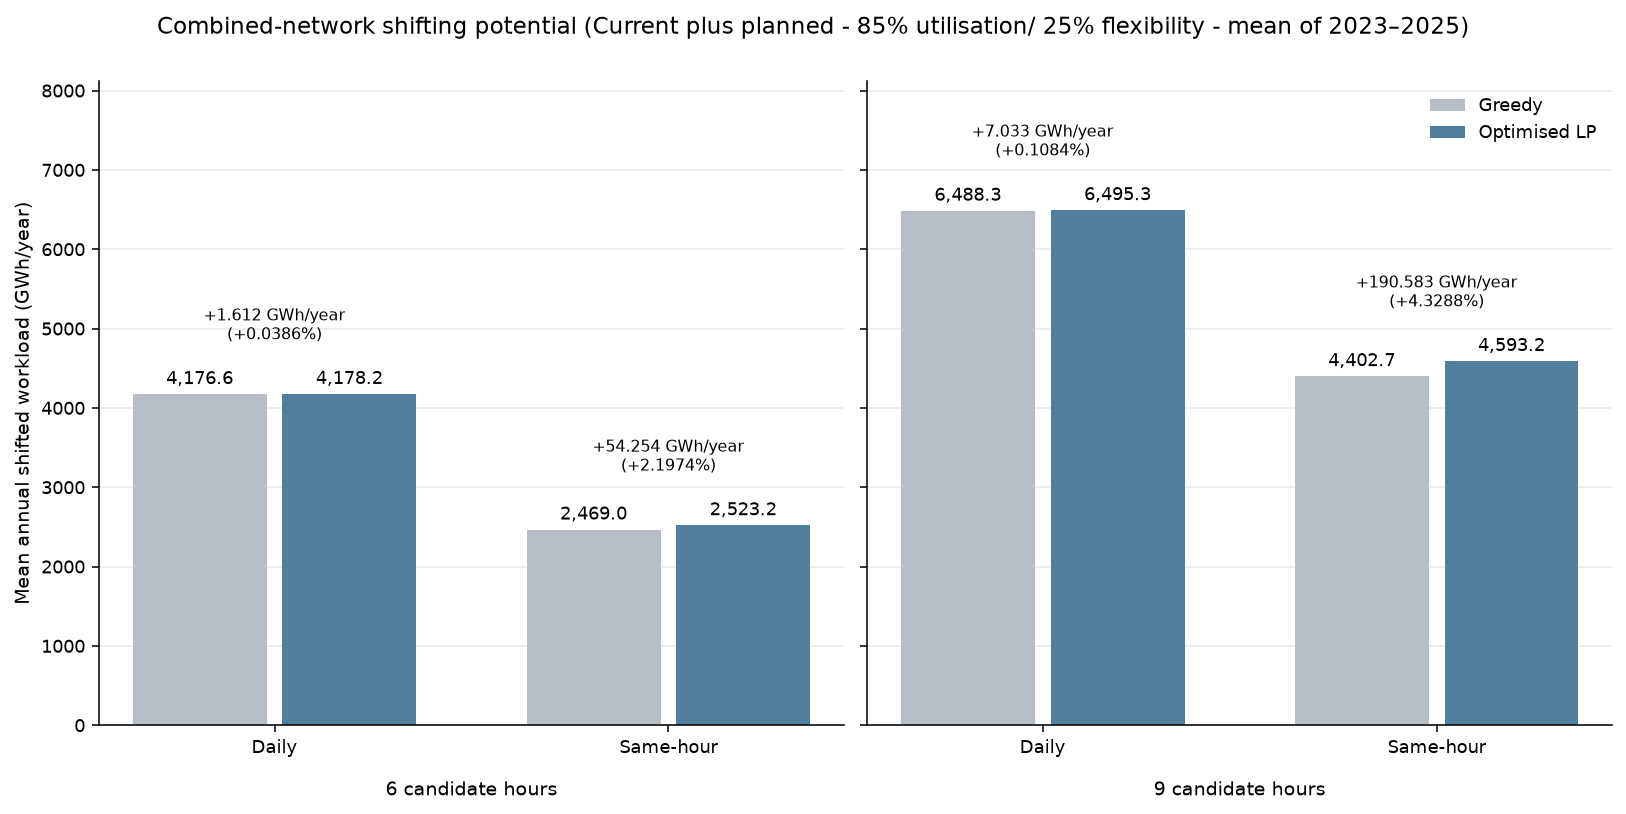

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.7), sharey=True, layout="constrained")

energy_limit = upper_axis(method_comparison[["greedy_mean_annual_shifted_gwh", "optimised_lp_mean_annual_shifted_gwh"]].to_numpy().ravel(), padding=0.25)

for ax, hours in zip(axes, CANDIDATE_HOURS):
    data = method_comparison.loc[method_comparison["candidate_hours"].eq(hours)].set_index("shift_mode").reindex(modes)
    x = np.arange(len(modes))
    for offset, method, label in [(-0.19, "greedy", "Greedy"), (0.19, "optimised_lp", "Optimised LP")]:
        bars = ax.bar(x + offset, data[f"{method}_mean_annual_shifted_gwh"], width=0.34, color=COLORS[method], label=label)
        ax.bar_label(bars, fmt="{:,.1f}", padding=3, fontsize=9)
    for position, (_, row) in enumerate(data.iterrows()):
        gap = row["lp_minus_greedy_mean_annual_gwh"]
        percent = row["lp_minus_greedy_percent_of_greedy"]
        percent_label = f"{percent:+.4f}%" if pd.notna(percent) else "undefined %"
        height = max(row["greedy_mean_annual_shifted_gwh"], row["optimised_lp_mean_annual_shifted_gwh"])
        ax.text(position, height + 0.085 * energy_limit, f"{gap:+.3f} GWh/year\n({percent_label})", ha="center", fontsize=8)
    ax.set(xticks=x,xticklabels=["Daily", "Same-hour"],ylim=(0, energy_limit))
    ax.set_xlabel(f"{hours} candidate hours", labelpad=12)
    ax.grid(True, axis="y", color="#e8e8e8")
    ax.set_axisbelow(True)

axes[0].set_ylabel("Mean annual shifted workload (GWh/year)")
axes[1].legend(frameon=False, loc="upper right")

fig.suptitle("Combined-network shifting potential (Current plus planned - 85% utilisation/ 25% flexibility - mean of 2023–2025)\n", fontsize=12)

save_figure(fig, "04a_shifting_potential_method_comparison", "main")

### 4b — Three-objective method comparison

Compare annual shifted energy, MWh-weighted renewable-index gain and MWh-weighted absolute time displacement for Greedy and LP. Each metric uses a common scale across the six-hour and nine-hour panels. These weighted averages describe the resulting allocations and do not directly test the sequential optimisation objectives.


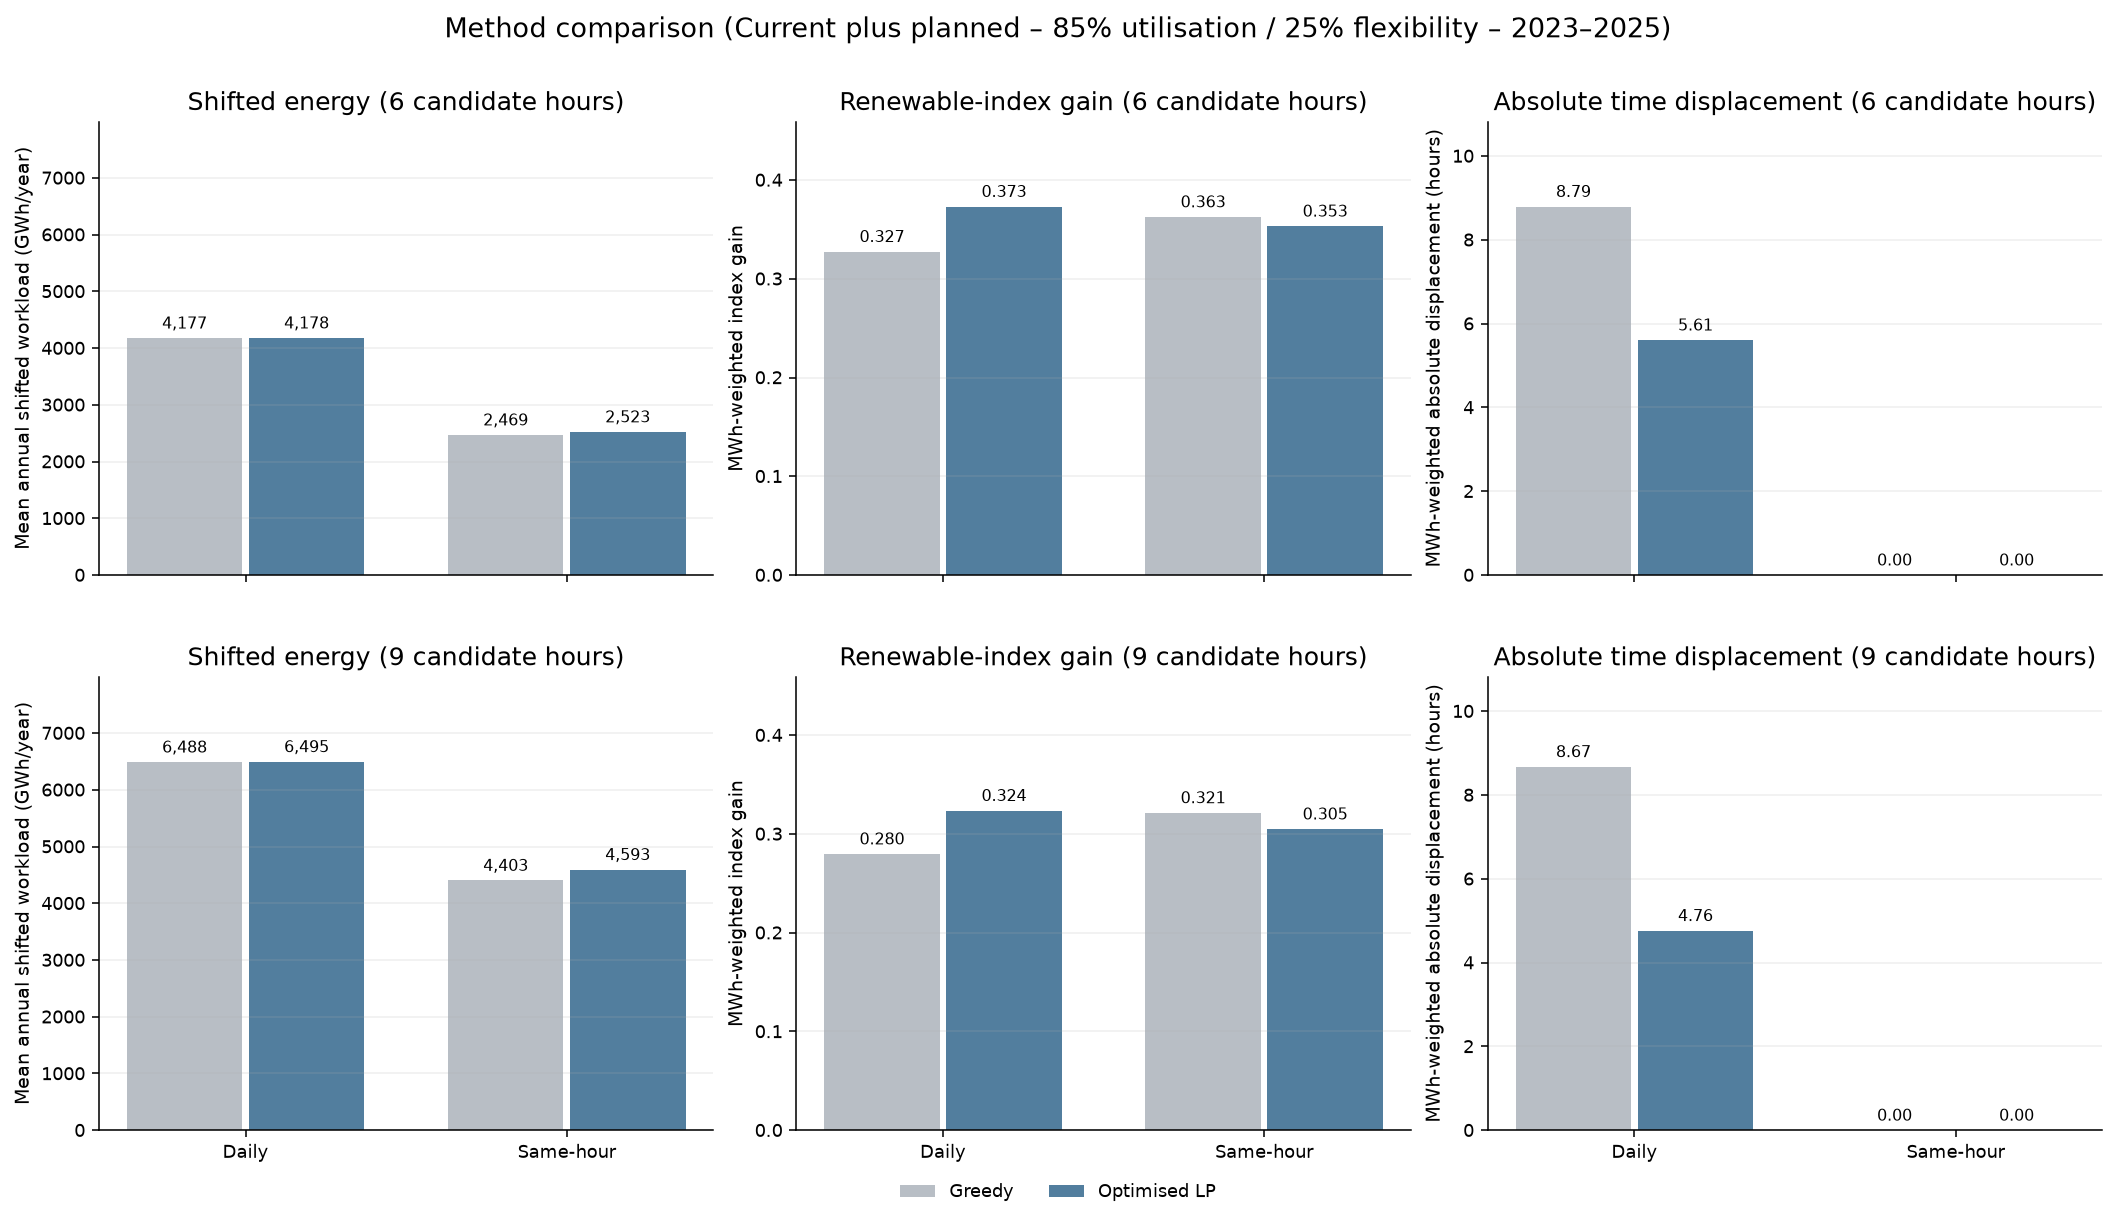

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.6), sharex=True, layout="constrained")
fig.get_layout_engine().set(hspace=0.10)
objective_metrics = [
    ("mean_annual_shifted_gwh", "Shifted energy", "Mean annual shifted workload (GWh/year)", ",.0f"),
    ("weighted_index_gain", "Renewable-index gain", "MWh-weighted index gain", ".3f"),
    ("weighted_time_hours", "Absolute time displacement", "MWh-weighted absolute displacement (hours)", ".2f"),
]
for row, hours in enumerate(CANDIDATE_HOURS):
    for col, (metric, title, ylabel, number_format) in enumerate(objective_metrics):
        ax = axes[row, col]
        for offset, method in zip((-0.19, 0.19), ALLOCATION_METHODS):
            values = objective_data.loc[(hours, method)].reindex(modes)[metric]
            bars = ax.bar(np.arange(len(modes)) + offset, values, width=0.36,
                color=COLORS[method],
                label="Greedy" if method == "greedy" else "Optimised LP")
            ax.bar_label(bars, labels=[format(value, number_format) if pd.notna(value) else "Undefined" for value in values], padding=3, fontsize=8)
        ax.set(xticks=range(2), xticklabels=["Daily", "Same-hour"],
            ylim=(0, upper_axis(objective_data[metric], padding=0.23)), ylabel=ylabel,
            title=f"{title} ({hours} candidate hours)")
        ax.grid(axis="y", alpha=0.2)
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Method comparison (Current plus planned – 85% utilisation / 25% flexibility – 2023–2025)\n", fontsize=14)

save_figure(fig, "04b_three_objective_method_comparison", "main")

## 5 — Candidate sender potential and receiver headroom

Calculate capped hourly load from capacity, utilisation and the local-clock profile, then derive sender potential at 25% flexibility and receiver headroom below the stored utilisation ceiling. Select sending and receiving hours independently from their UTC-day ranks for both candidate settings and all three utilisation assumptions. Average the annual limits for 2023–2025 and compare them with the completed LP allocations.


In [20]:
headroom_hourly = pd.read_parquet(
    DATA_INTERIM / "cluster_operator_hourly_load_and_flexibility.parquet",
    columns=["weather_year", "capacity_mw", "normalized_load_shape", "receive_utilisation_ceiling",
             "send_rank_daily", "receive_rank_daily"],
    filters=[("model_layer", "==", "current_plus_future")],
)

headroom_workloads = summaries["scenario_operator_year"].loc[
    summaries["scenario_operator_year"]["allocation_method"].eq("optimised_lp")
    & summaries["scenario_operator_year"]["model_layer"].eq("current_plus_future")
    & summaries["scenario_operator_year"]["flexibility_scenario_id"].eq(REFERENCE_FLEXIBILITY_ID)
].copy()

headroom_utilisations = headroom_workloads[
    ["utilisation_scenario_id", "base_utilisation"]
].drop_duplicates().sort_values("base_utilisation")

headroom_capacity = headroom_hourly["capacity_mw"].to_numpy()
headroom_shape = headroom_hourly["normalized_load_shape"].to_numpy()
headroom_ceiling = headroom_hourly["receive_utilisation_ceiling"].to_numpy()

headroom_parts = []
for workload in headroom_utilisations.itertuples(index=False):
    headroom_load = np.minimum(headroom_capacity * workload.base_utilisation * headroom_shape, headroom_capacity)
    headroom_available = np.maximum(headroom_capacity * headroom_ceiling - headroom_load, 0)
    for hours in CANDIDATE_HOURS:
        headroom_values = pd.DataFrame({
            "weather_year": headroom_hourly["weather_year"].to_numpy(),
            "sender_potential_mwh": np.where(headroom_hourly["send_rank_daily"].le(hours), 0.25 * headroom_load, 0),
            "receiver_headroom_mwh": np.where(headroom_hourly["receive_rank_daily"].le(hours), headroom_available, 0),
        }).groupby("weather_year", as_index=False).sum()
        headroom_values["candidate_hours"] = hours
        headroom_values["utilisation_scenario_id"] = workload.utilisation_scenario_id
        headroom_parts.append(headroom_values)

headroom_annual = pd.concat(headroom_parts, ignore_index=True)
headroom_keys = ["candidate_hours", "utilisation_scenario_id", "weather_year"]
headroom_achieved = headroom_workloads.groupby(headroom_keys + ["shift_mode"])["shifted_mwh"].sum().unstack("shift_mode")
headroom_annual = headroom_annual.merge(headroom_achieved.reset_index(), on=headroom_keys, validate="one_to_one")
headroom_measures = ["sender_potential_mwh", "receiver_headroom_mwh", *modes]
headroom_mean_gwh = (headroom_annual.groupby(["candidate_hours", "utilisation_scenario_id"])[headroom_measures].mean() / 1000).rename(
    columns={"sender_potential_mwh": "sender_potential_gwh", "receiver_headroom_mwh": "receiver_headroom_gwh"})

# Retain only the small annual and mean tables after the hourly calculation.
del headroom_hourly, headroom_capacity, headroom_shape, headroom_ceiling, headroom_load, headroom_available, headroom_values

### Candidate limits and achieved shifting

Plot candidate sender potential, receiver headroom and achieved LP energy on a shared scale for both candidate-hour settings. These aggregate limits do not account for whether individual senders and receivers can form a feasible transfer, including the matching UTC timestamps required for same-hour shifting.


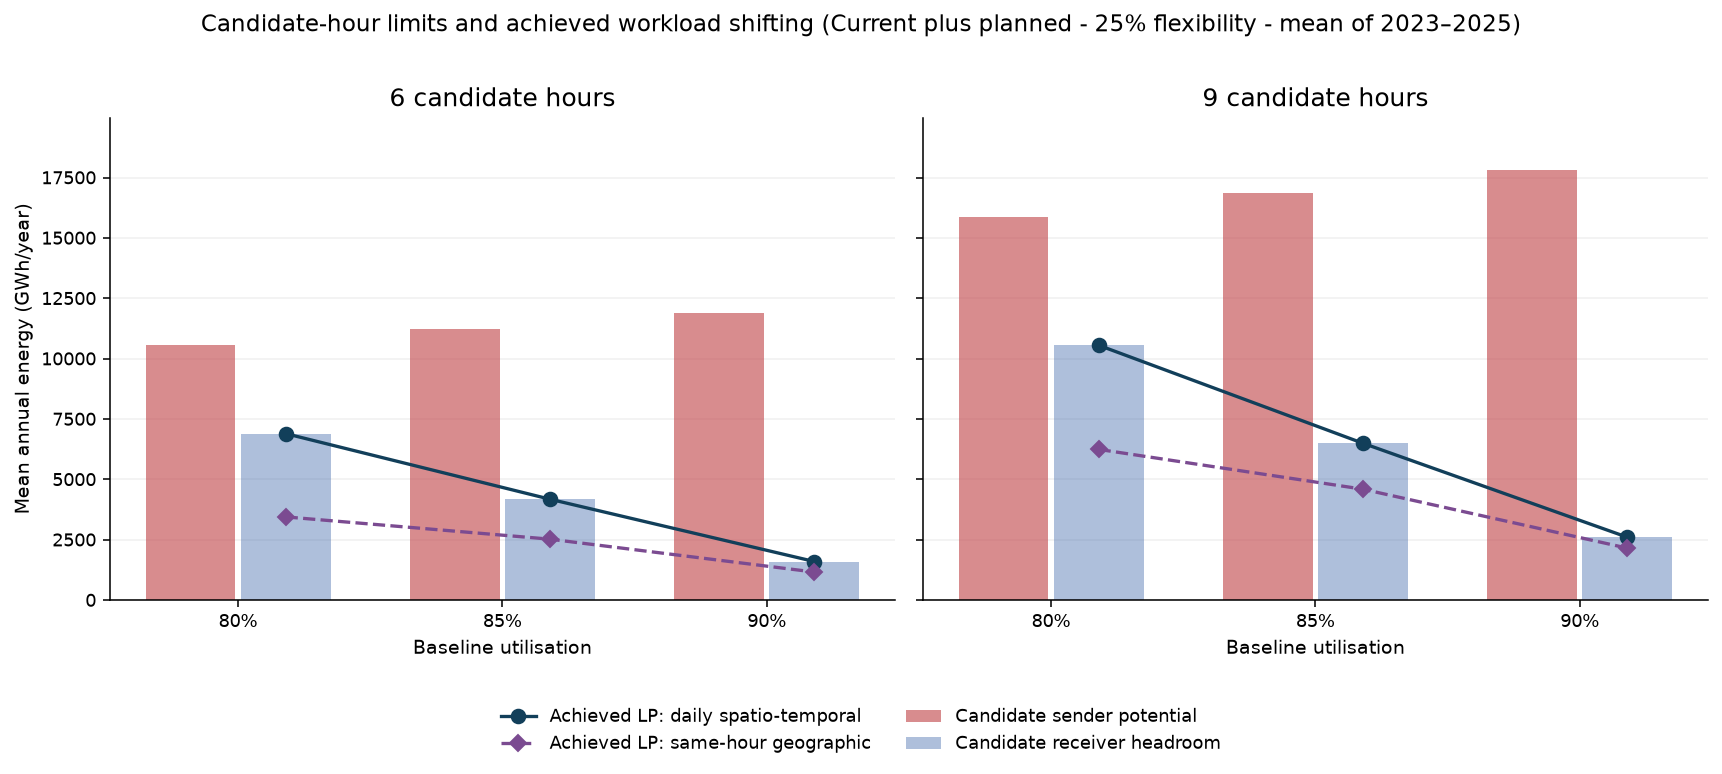

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.8), sharey=True)

headroom_x = np.arange(3)
headroom_plot_limit = upper_axis(headroom_mean_gwh.to_numpy().ravel(), padding=0.12)
for ax, hours in zip(axes, CANDIDATE_HOURS):
    headroom_panel = headroom_mean_gwh.loc[hours].reindex(["util_80", "util_85", "util_90"])
    ax.bar(headroom_x - 0.18, headroom_panel["sender_potential_gwh"], width=0.34,
           color=COLORS["send"], alpha=0.65, label="Candidate sender potential")
    ax.bar(headroom_x + 0.18, headroom_panel["receiver_headroom_gwh"], width=0.34,
           color=COLORS["receive"], alpha=0.45, label="Candidate receiver headroom")
    ax.plot(headroom_x + 0.18, headroom_panel["daily_spatiotemporal"], color="#123f5a",
            marker="o", markersize=7, linewidth=1.7, label="Achieved LP: daily spatio-temporal")
    ax.plot(headroom_x + 0.18, headroom_panel["same_hour_geographic"], color="#7b4b91",
            marker="D", markersize=6, linewidth=1.7, linestyle="--", label="Achieved LP: same-hour geographic")
    ax.set(xticks=headroom_x, xticklabels=["80%", "85%", "90%"], xlabel="Baseline utilisation",
           title=f"{hours} candidate hours", ylim=(0, headroom_plot_limit))
    ax.grid(axis="y", alpha=0.18)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Mean annual energy (GWh/year)")

fig.suptitle("Candidate-hour limits and achieved workload shifting (Current plus planned - 25% flexibility - mean of 2023–2025)", fontsize=12)
headroom_handles, headroom_labels = axes[0].get_legend_handles_labels()
fig.legend(headroom_handles, headroom_labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.05))
fig.tight_layout(rect=(0, 0.16, 1, 0.97))

save_figure(fig, "05_candidate_energy_limits", "main")

## 6 — Workload sensitivity

Retain all nine combinations of 80%/85%/90% utilisation and 20%/25%/30% flexibility for LP with current plus planned locations. Calculate mean annual shifted network energy and arrange the workload matrices.

In [22]:
scenario_annual = summaries["scenario_operator_year"].loc[
    summaries["scenario_operator_year"]["allocation_method"].eq("optimised_lp")
    & summaries["scenario_operator_year"]["model_layer"].eq("current_plus_future")]
scenario_keys = ["candidate_hours", "shift_mode", "utilisation_scenario_id", "flexibility_scenario_id"]
scenario_annual = scenario_annual.groupby(scenario_keys + ["weather_year"], as_index=False)["shifted_mwh"].sum()
scenario_mean = scenario_annual.groupby(scenario_keys)["shifted_mwh"].mean() / 1000

matrices = {}
for hours in CANDIDATE_HOURS:
    for mode in modes:
        matrices[(hours, mode)] = scenario_mean.loc[(hours, mode)].unstack("flexibility_scenario_id").reindex(
            index=["util_80", "util_85", "util_90"], columns=["flex_20", "flex_25", "flex_30"])

matrix_vmax = upper_axis(scenario_mean, padding=0)

### Workload-sensitivity matrix

Plot the full 3×3 workload grid for each shifting mode and candidate-hour setting on a common energy scale. Label each cell with mean annual shifted GWh.

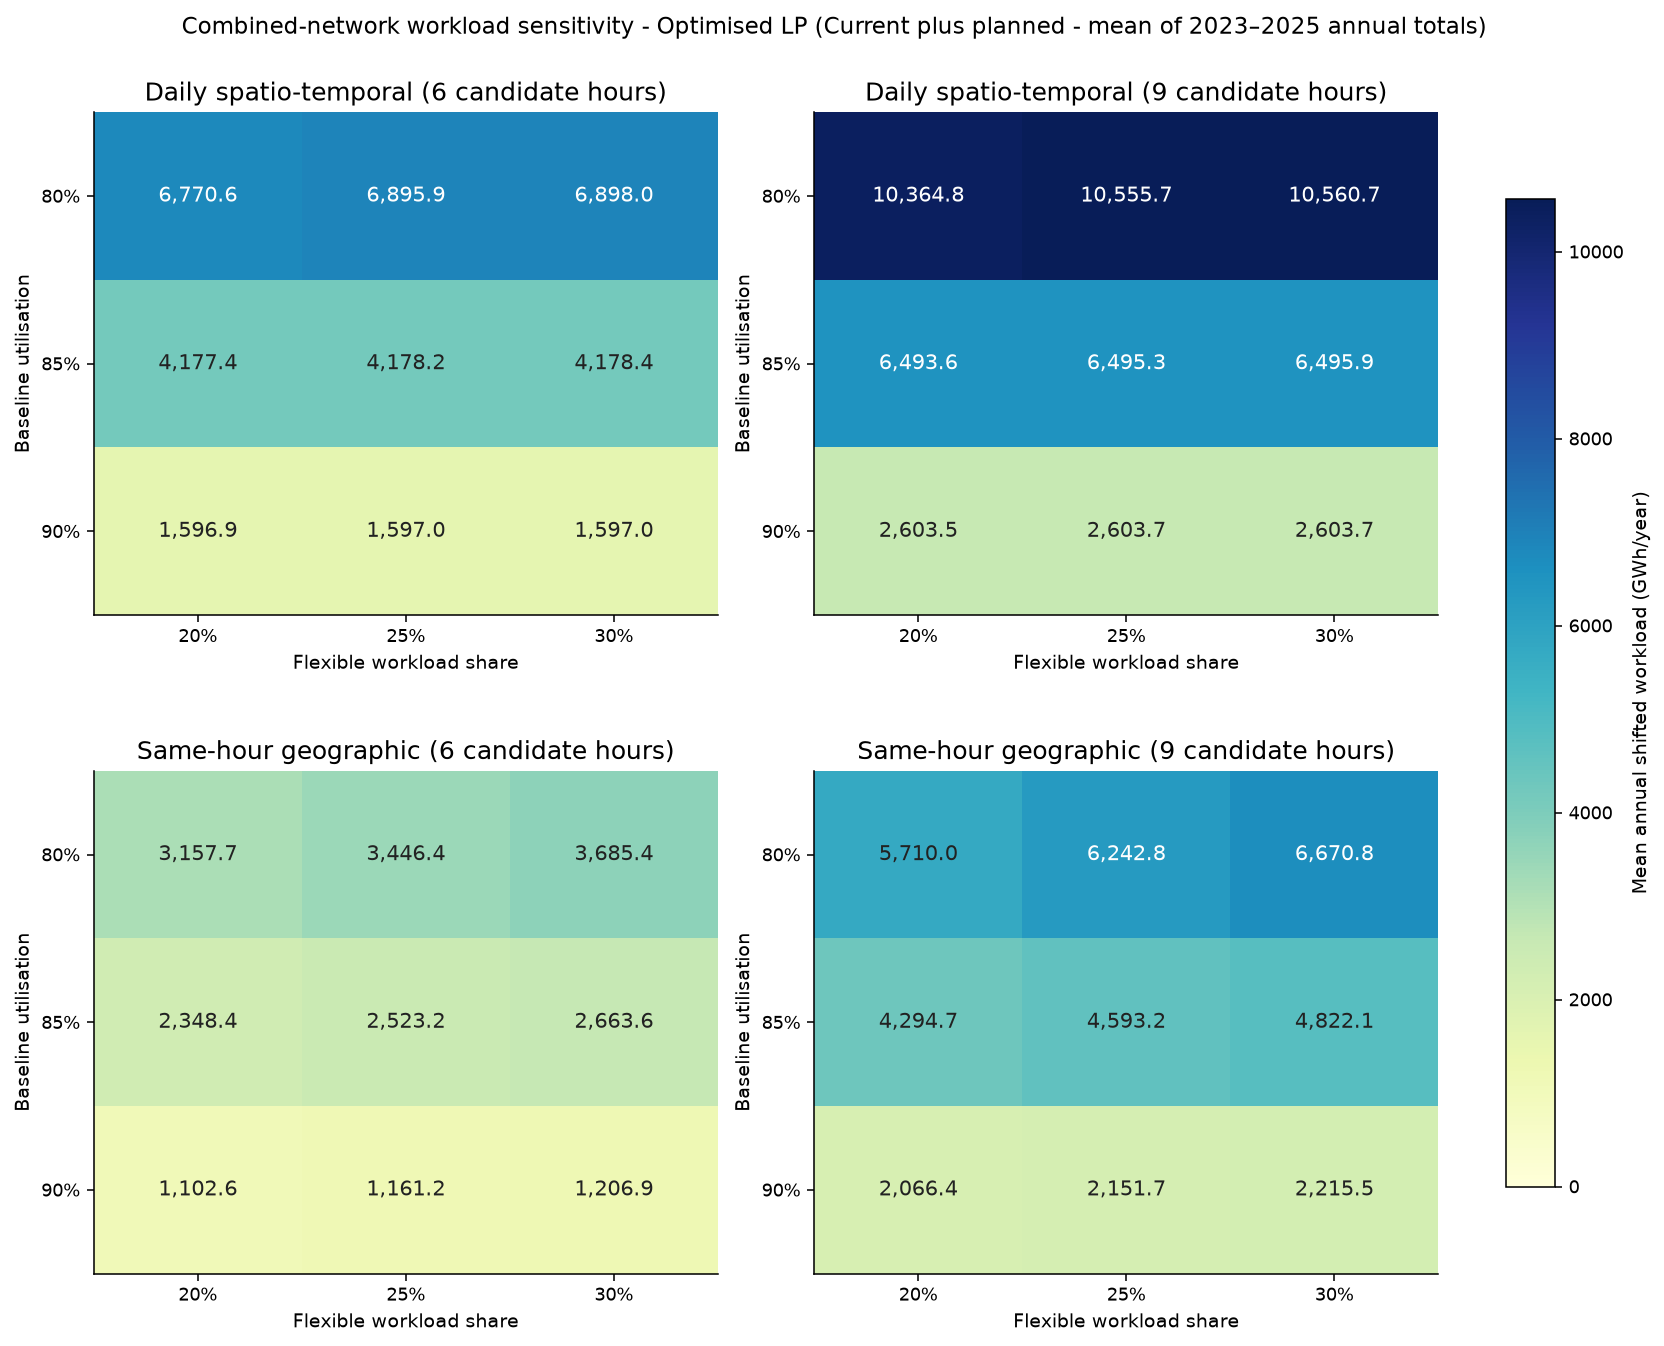

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11.8, 9.5), layout="constrained")
fig.get_layout_engine().set(hspace=0.10)
matrix_cmap = plt.get_cmap("YlGnBu").copy()
matrix_cmap.set_bad("#e0e0e0")
for row_index, mode in enumerate(modes):
    for col_index, hours in enumerate(CANDIDATE_HOURS):
        ax = axes[row_index, col_index]
        matrix = matrices[(hours, mode)]
        heat = ax.imshow(np.ma.masked_invalid(matrix.to_numpy()), cmap=matrix_cmap, vmin=0, vmax=matrix_vmax, aspect="auto")
        ax.set(xticks=range(3), xticklabels=["20%", "25%", "30%"], yticks=range(3), yticklabels=["80%", "85%", "90%"],
            xlabel="Flexible workload share", ylabel="Baseline utilisation", title=f"{mode_labels[mode]} ({hours} candidate hours)")
        for row in range(3):
            for col in range(3):
                value = matrix.iloc[row, col]
                label = f"{value:,.1f}" if pd.notna(value) else "Missing"
                ax.text(col, row, label, ha="center", va="center", fontsize=11,
                    color="white" if pd.notna(value) and heat.norm(value) > 0.55 else "#222")

fig.colorbar(heat, ax=axes.ravel().tolist(), label="Mean annual shifted workload (GWh/year)", shrink=0.85)
fig.suptitle("Combined-network workload sensitivity - Optimised LP (Current plus planned - mean of 2023–2025 annual totals)\n", fontsize=12)

save_figure(fig, "06_workload_sensitivity_matrix", "main")

## 7 — Geographic flows

Define a function to sum shifted energy by directed query-location pair, select the largest flows and attach sender and receiver coordinates for the geographic maps.

In [24]:
def prepare_top_flows(flows, coords, top_n=35):
    top = (flows.groupby(["sender_query_location_id", "receiver_query_location_id"], as_index=False)
           ["shifted_mwh"].sum().nlargest(top_n, "shifted_mwh"))
    for side in ("sender", "receiver"):
        top = top.merge(coords.rename(columns={"query_location_id": f"{side}_query_location_id",
                            "representative_lat": f"{side}_lat", "representative_lon": f"{side}_lon"}),
                        on=f"{side}_query_location_id", how="left", validate="many_to_one")
    if top[["sender_lat", "sender_lon", "receiver_lat", "receiver_lon"]].isna().any().any():
        raise ValueError("A plotted allocation endpoint has no query coordinate")
    return top

### Prepare regional totals and directed flows

Reconcile each reference partition with the annual summaries and check daily partitions against their daily totals. Prepare the top 12 sender and receiver query regions for each daily method and the top 35 directed pairs for each LP mode and candidate-hour setting. Aggregate every LP transfer by world region and weather year for the complete regional composition comparison.


In [25]:
regional_annual_parts = []
query_world_regions = query_locations.set_index("query_location_id")["world_region"]
region_summaries = {}
top_flows = {}

for (hours, method, mode), path in partition_paths.items():
    columns = ["model_layer", "weather_year", "shifted_mwh"]
    if mode == "daily_spatiotemporal":
        columns += ["sender_renewable_query_region", "receiver_renewable_query_region"]
    if method == "optimised_lp":
        columns += ["sender_query_location_id", "receiver_query_location_id"]
    detail = pd.read_parquet(path, columns=columns)
    selected = detail.loc[detail["model_layer"].eq("current_plus_future")]
    if mode == "daily_spatiotemporal":
        sender = selected.groupby("sender_renewable_query_region", as_index=False)["shifted_mwh"].sum().nlargest(12, "shifted_mwh")
        receiver = selected.groupby("receiver_renewable_query_region", as_index=False)["shifted_mwh"].sum().nlargest(12, "shifted_mwh")
        sender["shifted_gwh"], receiver["shifted_gwh"] = sender["shifted_mwh"] / 1000, receiver["shifted_mwh"] / 1000
        region_summaries[(hours, method)] = (sender, receiver)
    if method == "optimised_lp":
        sender_world_region = selected["sender_query_location_id"].map(query_world_regions)
        receiver_world_region = selected["receiver_query_location_id"].map(query_world_regions)
        if sender_world_region.isna().any() or receiver_world_region.isna().any():
            raise ValueError("Every allocation endpoint needs a world-region mapping")
        region_energy = selected[["weather_year", "shifted_mwh"]].assign(
            flow_scope=np.where(sender_world_region.eq(receiver_world_region), "Within world region", "Between world regions"))
        region_energy = region_energy.groupby(["weather_year", "flow_scope"])["shifted_mwh"].sum().reindex(
            pd.MultiIndex.from_product([weather_years, ["Within world region", "Between world regions"]],
                names=["weather_year", "flow_scope"]), fill_value=0).reset_index()
        region_energy["candidate_hours"], region_energy["shift_mode"] = hours, mode
        regional_annual_parts.append(region_energy)
        del sender_world_region, receiver_world_region, region_energy
        flows = prepare_top_flows(selected, coords, top_n=35)
        flows["mean_annual_shifted_gwh"] = flows["shifted_mwh"] / (1000 * len(weather_years))
        top_flows[(hours, mode)] = flows
    del detail, selected

region_xlim = (0, upper_axis(pd.concat([frame["shifted_gwh"] for pair in region_summaries.values() for frame in pair], ignore_index=True)))
flow_maximum = max((float(frame["mean_annual_shifted_gwh"].max()) for frame in top_flows.values() if not frame.empty), default=0.0)

### Geographic flow map function

Define a shared drawing function for the four LP flow maps. Use consistent boundaries, coordinates, arrow widths and legends so the mode and candidate-hour comparisons share the same scale.


In [26]:
def plot_geographic_flow(flows, world, *, candidate_hours, mode_label, flow_maximum, colours):
    fig, ax = plt.subplots(figsize=(13, 7.5), layout="constrained")
    world.plot(ax=ax, color="#f4f4f2", edgecolor="#c6c6c6", linewidth=0.35)
    ax.set(xlim=(-180, 180), ylim=(-58, 82), xlabel="Longitude", ylabel="Latitude")
    ax.grid(True, color="#e8e8e8", linewidth=0.5)
    for flow in flows.itertuples():
        relative = flow.mean_annual_shifted_gwh / flow_maximum if flow_maximum > 0 else 0.0
        start = (flow.sender_lon, flow.sender_lat)
        end = (flow.receiver_lon, flow.receiver_lat)
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=10,
            linewidth=0.7 + 4.5 * relative, color=colours["optimised_lp"],
            alpha=0.25 + 0.55 * relative, connectionstyle="arc3,rad=0.12"))
    for side, color in (("sender", colours["send"]), ("receiver", colours["receive"])):
        ax.scatter(flows[f"{side}_lon"], flows[f"{side}_lat"], s=28, color=color,
            edgecolor="white", linewidth=0.5, label=side.title())
    ax.set_title(f"{mode_label} - {candidate_hours} candidate hours (top 35 pairs)", fontsize=12, pad=20)
    ax.legend(frameon=False, loc="upper right", fontsize=9)
    fig.suptitle("Modelled workload-flow geography - Optimised LP (Current plus planned - 85%/25% - mean annual energy, 2023–2025)", fontsize=12, y=0.92)
    return fig


### 7a — Daily geographic allocation: 6 candidate hours

Map the top 35 daily LP flows for six candidate hours with current plus planned locations at 85% utilisation and 25% flexibility. Arrow widths show mean annual shifted GWh over 2023–2025. The selected workload-flow pattern can be one of several equally optimal LP allocations.


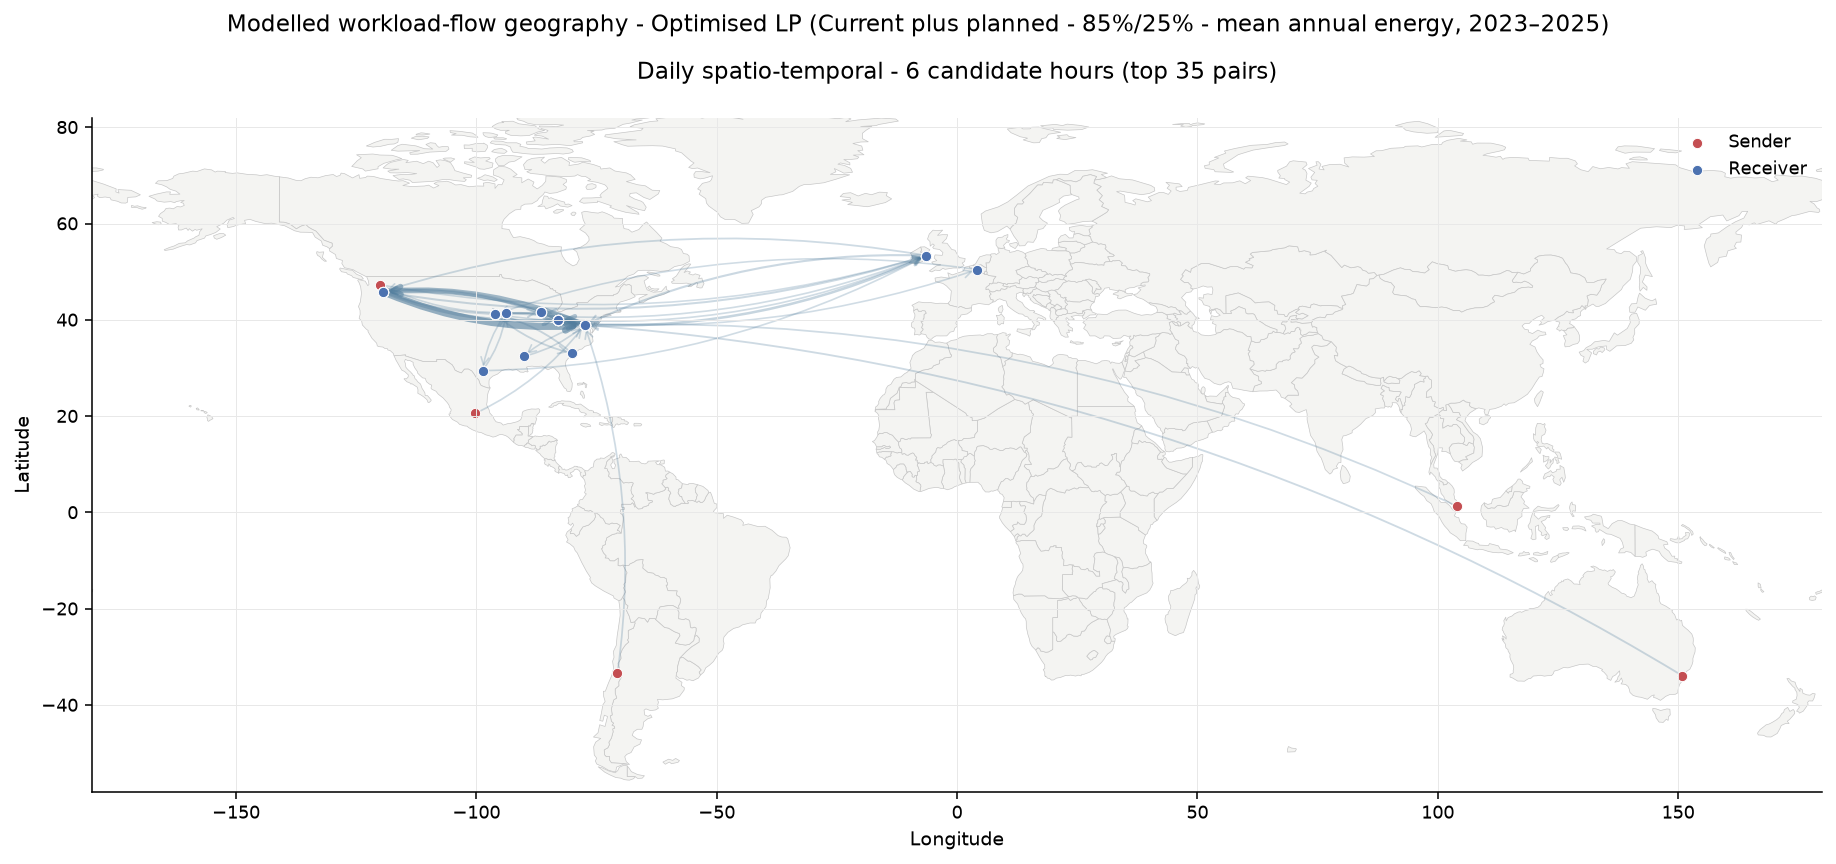

In [27]:
fig = plot_geographic_flow(
    top_flows[(6, "daily_spatiotemporal")], world,
    candidate_hours=6, mode_label=mode_labels["daily_spatiotemporal"],
    flow_maximum=flow_maximum, colours=COLORS,
)

save_figure(fig, "07a_geographic_flow_daily_6h", "main")

### 7b — Daily geographic allocation: 9 candidate hours

Map the top 35 daily LP flows for nine candidate hours at the same reference workload assumptions. Use the shared arrow-width scale to compare mean annual shifted energy with the six-hour case.


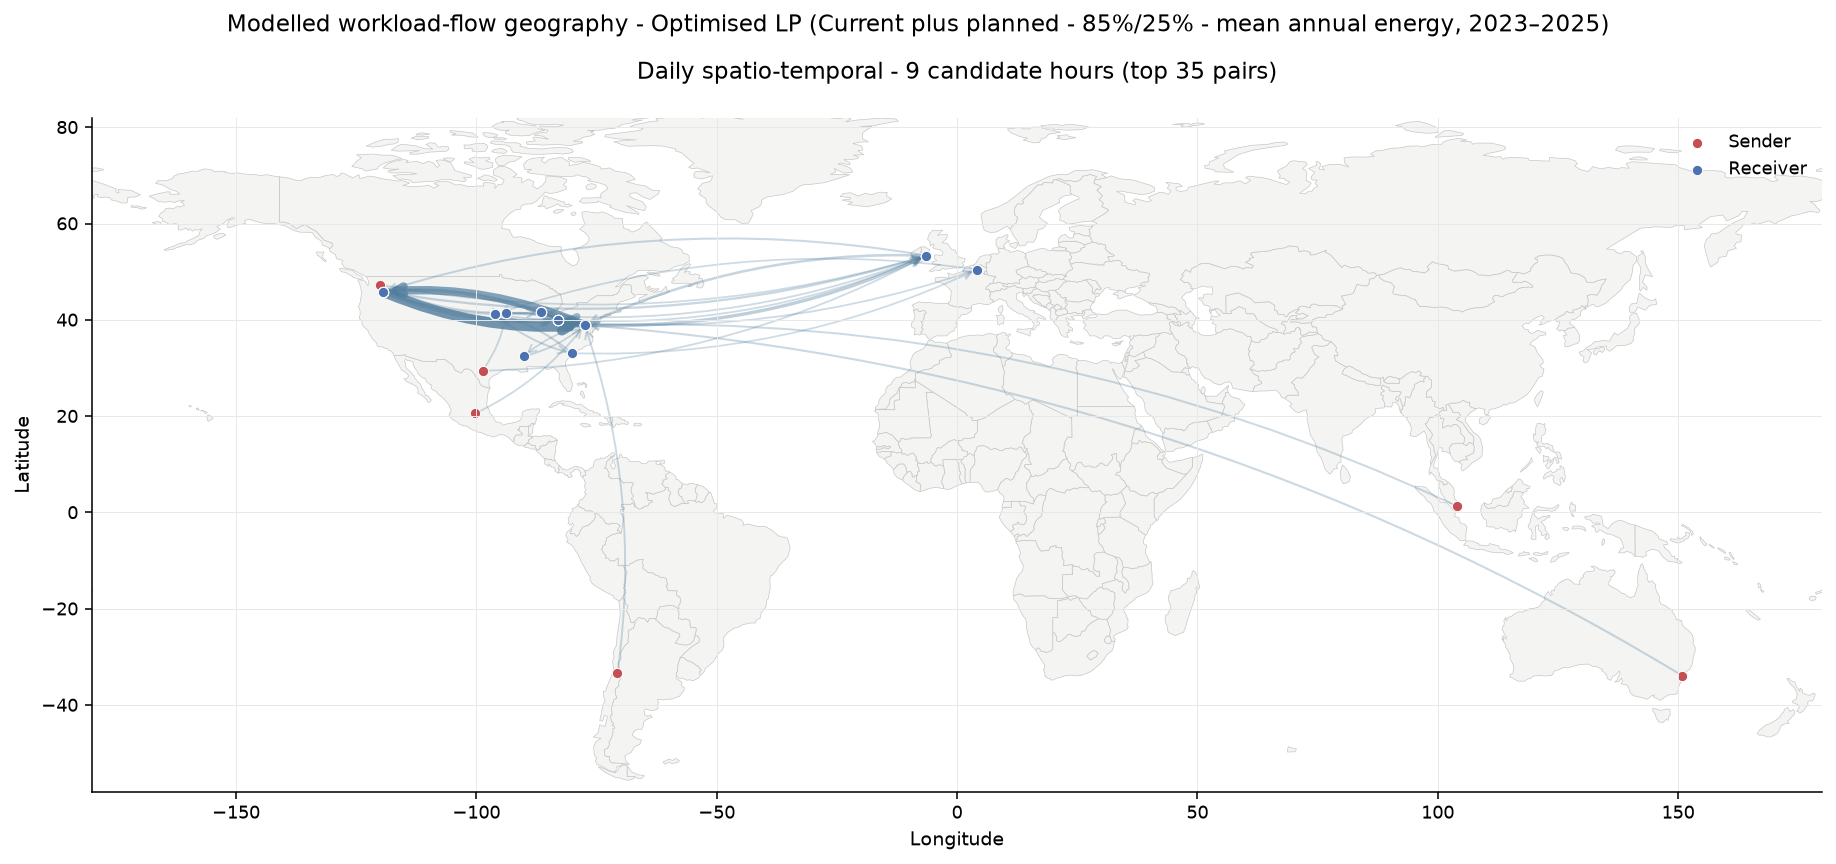

In [28]:
fig = plot_geographic_flow(
    top_flows[(9, "daily_spatiotemporal")], world,
    candidate_hours=9, mode_label=mode_labels["daily_spatiotemporal"],
    flow_maximum=flow_maximum, colours=COLORS,
)

save_figure(fig, "07b_geographic_flow_daily_9h", "main")

### 7c — Same-hour geographic allocation: 6 candidate hours

Map the top 35 same-hour LP flows for six candidate hours at the reference workload assumptions. The shared arrow-width scale shows mean annual shifted energy for transfers that retain the same UTC timestamp.


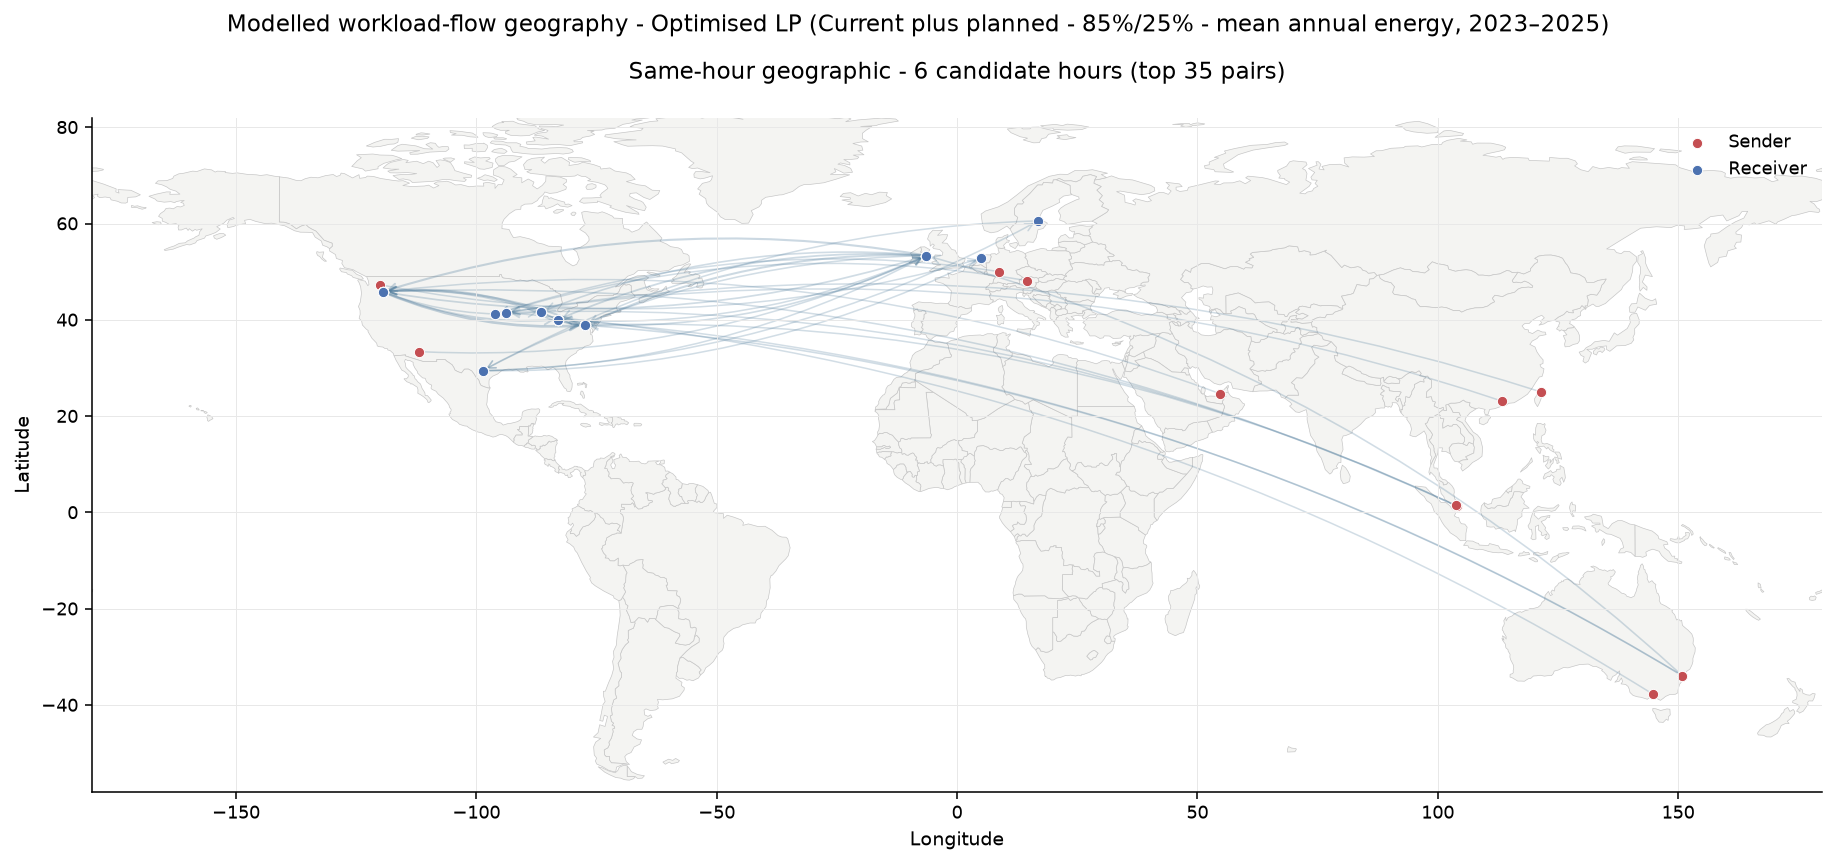

In [29]:
fig = plot_geographic_flow(
    top_flows[(6, "same_hour_geographic")], world,
    candidate_hours=6, mode_label=mode_labels["same_hour_geographic"],
    flow_maximum=flow_maximum, colours=COLORS,
)

save_figure(fig, "07c_geographic_flow_same_hour_6h", "main")

### 7d — Same-hour geographic allocation: 9 candidate hours

Map the top 35 same-hour LP flows for nine candidate hours at the reference workload assumptions. Retain the common coordinates, map extent and arrow-width scale used in the other three flow maps.


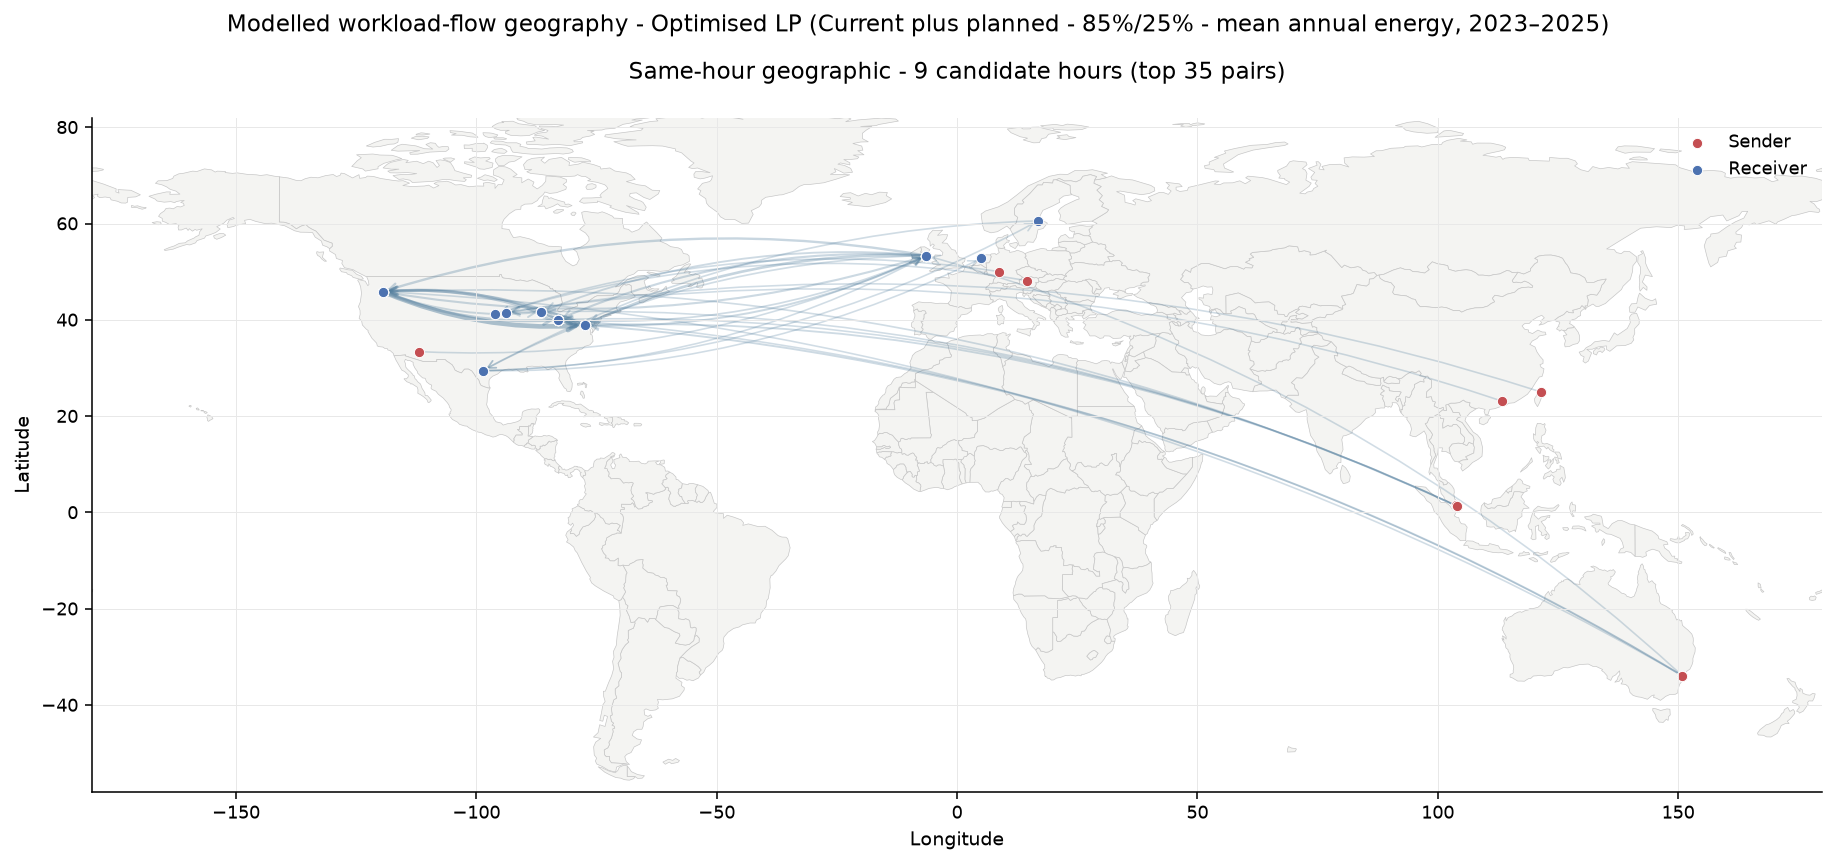

In [30]:
fig = plot_geographic_flow(
    top_flows[(9, "same_hour_geographic")], world,
    candidate_hours=9, mode_label=mode_labels["same_hour_geographic"],
    flow_maximum=flow_maximum, colours=COLORS,
)

save_figure(fig, "07d_geographic_flow_same_hour_9h", "main")

## 8 — Regional composition

Check that the within-region and between-region LP totals sum to annual network energy. Average each component over the same three weather years so the stacked values add to mean annual network energy.


In [31]:
regional_annual = pd.concat(regional_annual_parts, ignore_index=True)
regional_means = regional_annual.groupby(["candidate_hours", "shift_mode", "flow_scope"])["shifted_mwh"].mean().unstack("flow_scope") / 1000
regional_means = regional_means.reindex(columns=["Within world region", "Between world regions"])

display(regional_means)

flow_scope                            Within world region  \
candidate_hours shift_mode                                  
6               daily_spatiotemporal          2200.503829   
                same_hour_geographic           575.500505   
9               daily_spatiotemporal          3429.885548   
                same_hour_geographic          1472.735553   

flow_scope                            Between world regions  
candidate_hours shift_mode                                   
6               daily_spatiotemporal            1977.664460  
                same_hour_geographic            1947.714822  
9               daily_spatiotemporal            3065.441609  
                same_hour_geographic            3120.508607

### 8a — Within- and between-world-region shifting

Stack mean annual LP energy within and between world regions and label each component's share for both shifting modes and candidate-hour settings. These broad geographical categories describe the selected allocation without establishing latency, bandwidth or data-sovereignty feasibility.


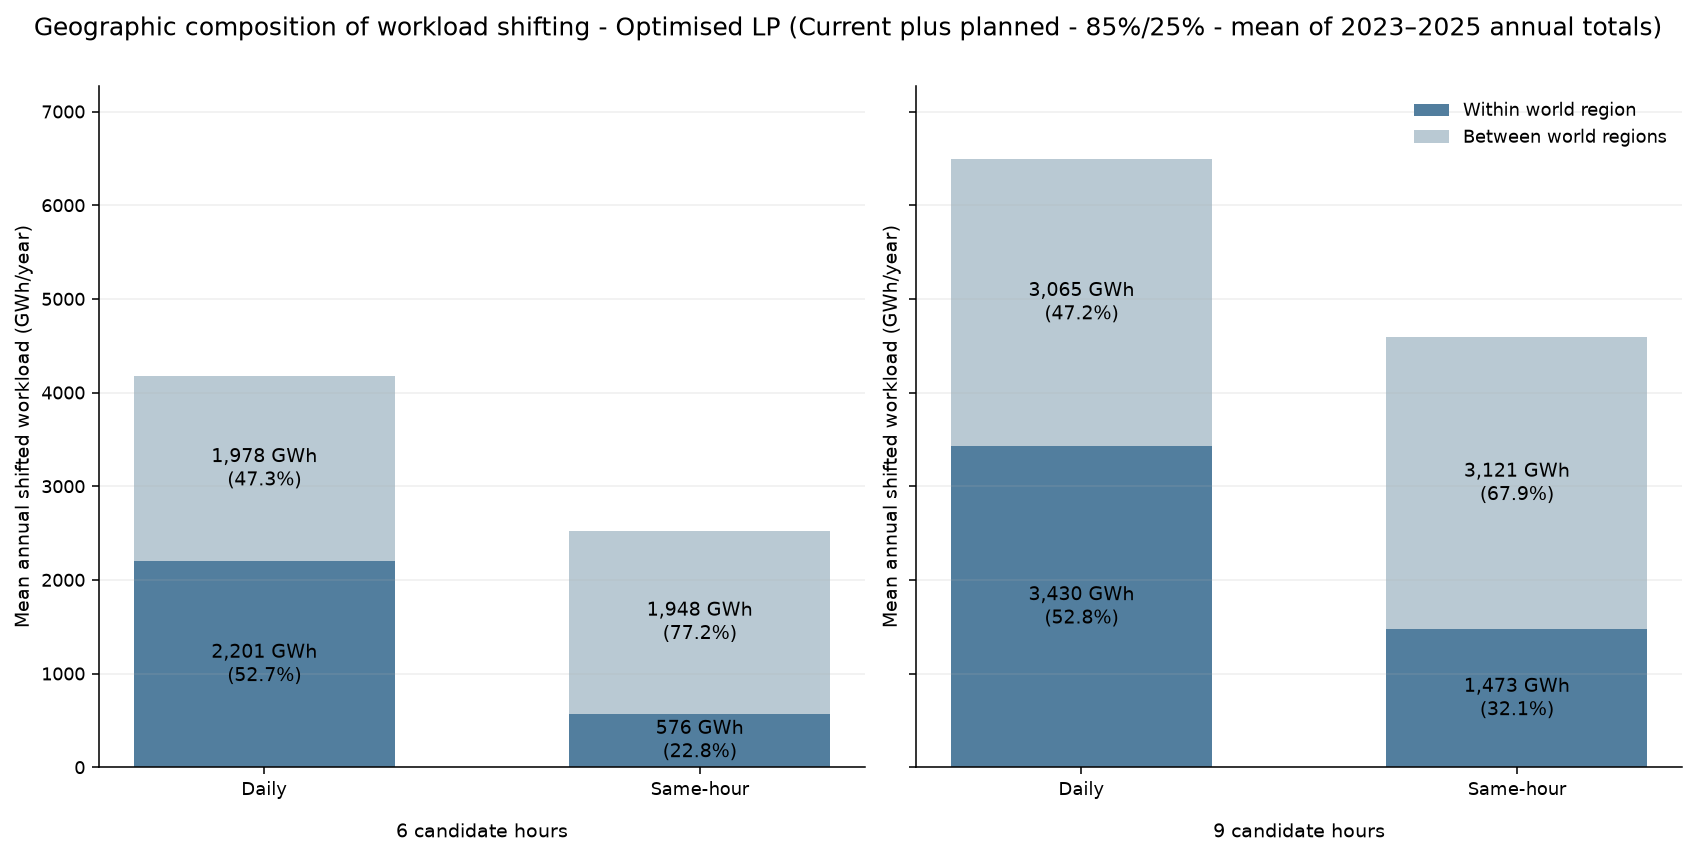

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, layout="constrained")

for ax, hours in zip(axes, CANDIDATE_HOURS):
    values = regional_means.loc[hours].reindex(modes)
    totals = values.sum(axis=1)
    bottom = np.zeros(len(modes))
    for scope, colour in (("Within world region", "#527e9e"),("Between world regions", "#b9c9d3")):
        component = values[scope].to_numpy()
        bars = ax.bar(range(2), component, bottom=bottom, color=colour, label=scope, width=0.6)
        shares = 100 * component / totals.to_numpy()
        ax.bar_label(bars, labels=[f"{energy:,.0f} GWh\n({share:.1f}%)" for energy, share in zip(component, shares)], label_type="center", fontsize=10)
        bottom += component
    ax.set(xticks=range(2), xticklabels=["Daily", "Same-hour"], ylabel="Mean annual shifted workload (GWh/year)", ylim=(0, upper_axis(regional_means.sum(axis=1))))
    ax.set_xlabel(f"{hours} candidate hours", labelpad=12)
    ax.grid(axis="y", alpha=0.2)

axes[1].legend(loc="upper right", frameon=False)

fig.suptitle( "Geographic composition of workload shifting - Optimised LP " "(Current plus planned - 85%/25% - mean of 2023–2025 annual totals)\n", fontsize=13)

save_figure(fig, "08a_within_between_world_regions", "main")

### 8b — Leading sender and receiver regions: Greedy

Plot Greedy's top 12 sender and receiver query regions for daily shifting with current plus planned locations at the reference workload assumptions. Values are cumulative GWh over 2023–2025, using common scales across methods and candidate-hour settings.


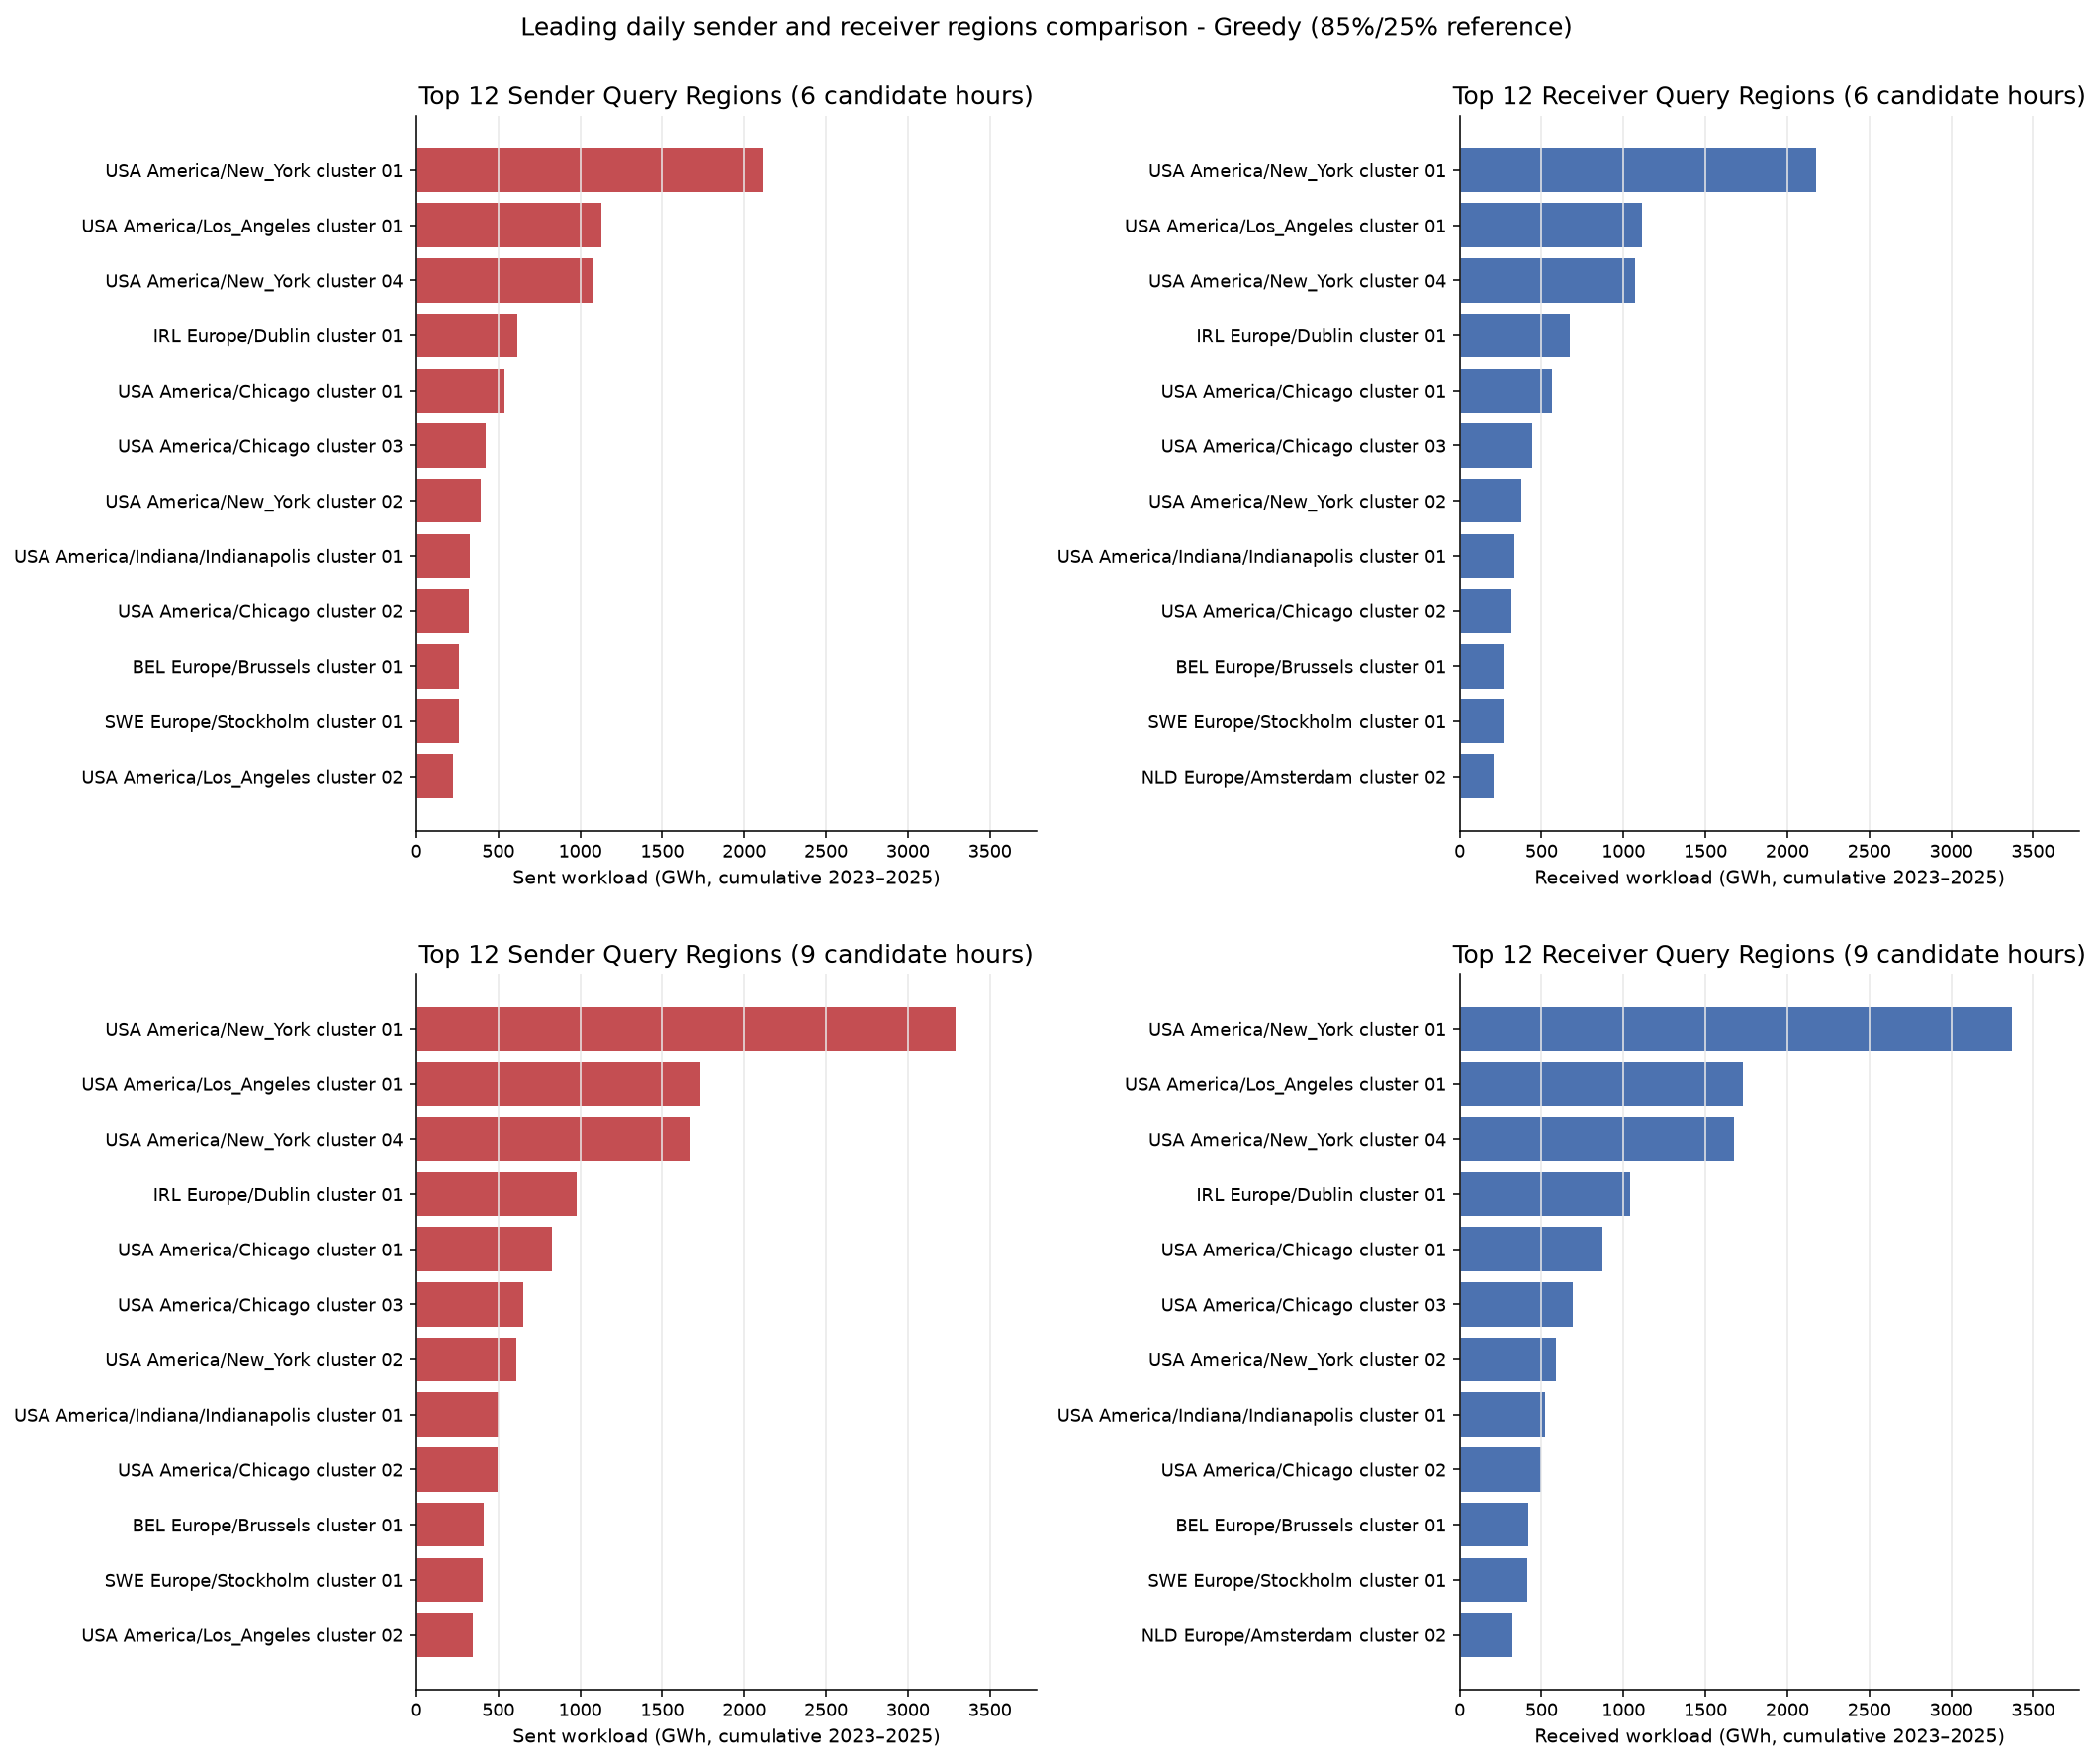

In [33]:
fig = plt.figure(figsize=(15, 12.6), layout="constrained")
panels = fig.subfigures(2, 1, hspace=0.05)

fig.suptitle(f"Leading daily sender and receiver regions comparison - Greedy (85%/25% reference)\n", fontsize=13)

for hours, panel in zip(CANDIDATE_HOURS, panels):
    axes = panel.subplots(1, 2)
    sender, receiver = region_summaries[(hours, "greedy")]
    for ax, data, side, label in zip(axes, (sender, receiver), ("sender", "receiver"), ("Sent", "Received")):
        ax.barh(data[f"{side}_renewable_query_region"][::-1], data["shifted_gwh"][::-1], color=COLORS["send" if side == "sender" else "receive"])
        ax.set(title=f"Top 12 {side.title()} Query Regions ({hours} candidate hours)", xlabel=f"{label} workload (GWh, cumulative 2023–2025)", xlim=region_xlim)
        ax.grid(True, axis="x", color="#e8e8e8")
        if data.empty:
            ax.text(0.5, 0.5, "No shifted workload", transform=ax.transAxes, ha="center", va="center", color="#555")

save_figure(fig, "08b_top_sender_receiver_regions", "greedy")

### 8c — Leading sender and receiver regions: Optimised LP

Plot LP's top 12 sender and receiver query regions for the same daily reference case and period. Use the same scale as Greedy, while recognising that equally optimal LP allocations can have different regional patterns.


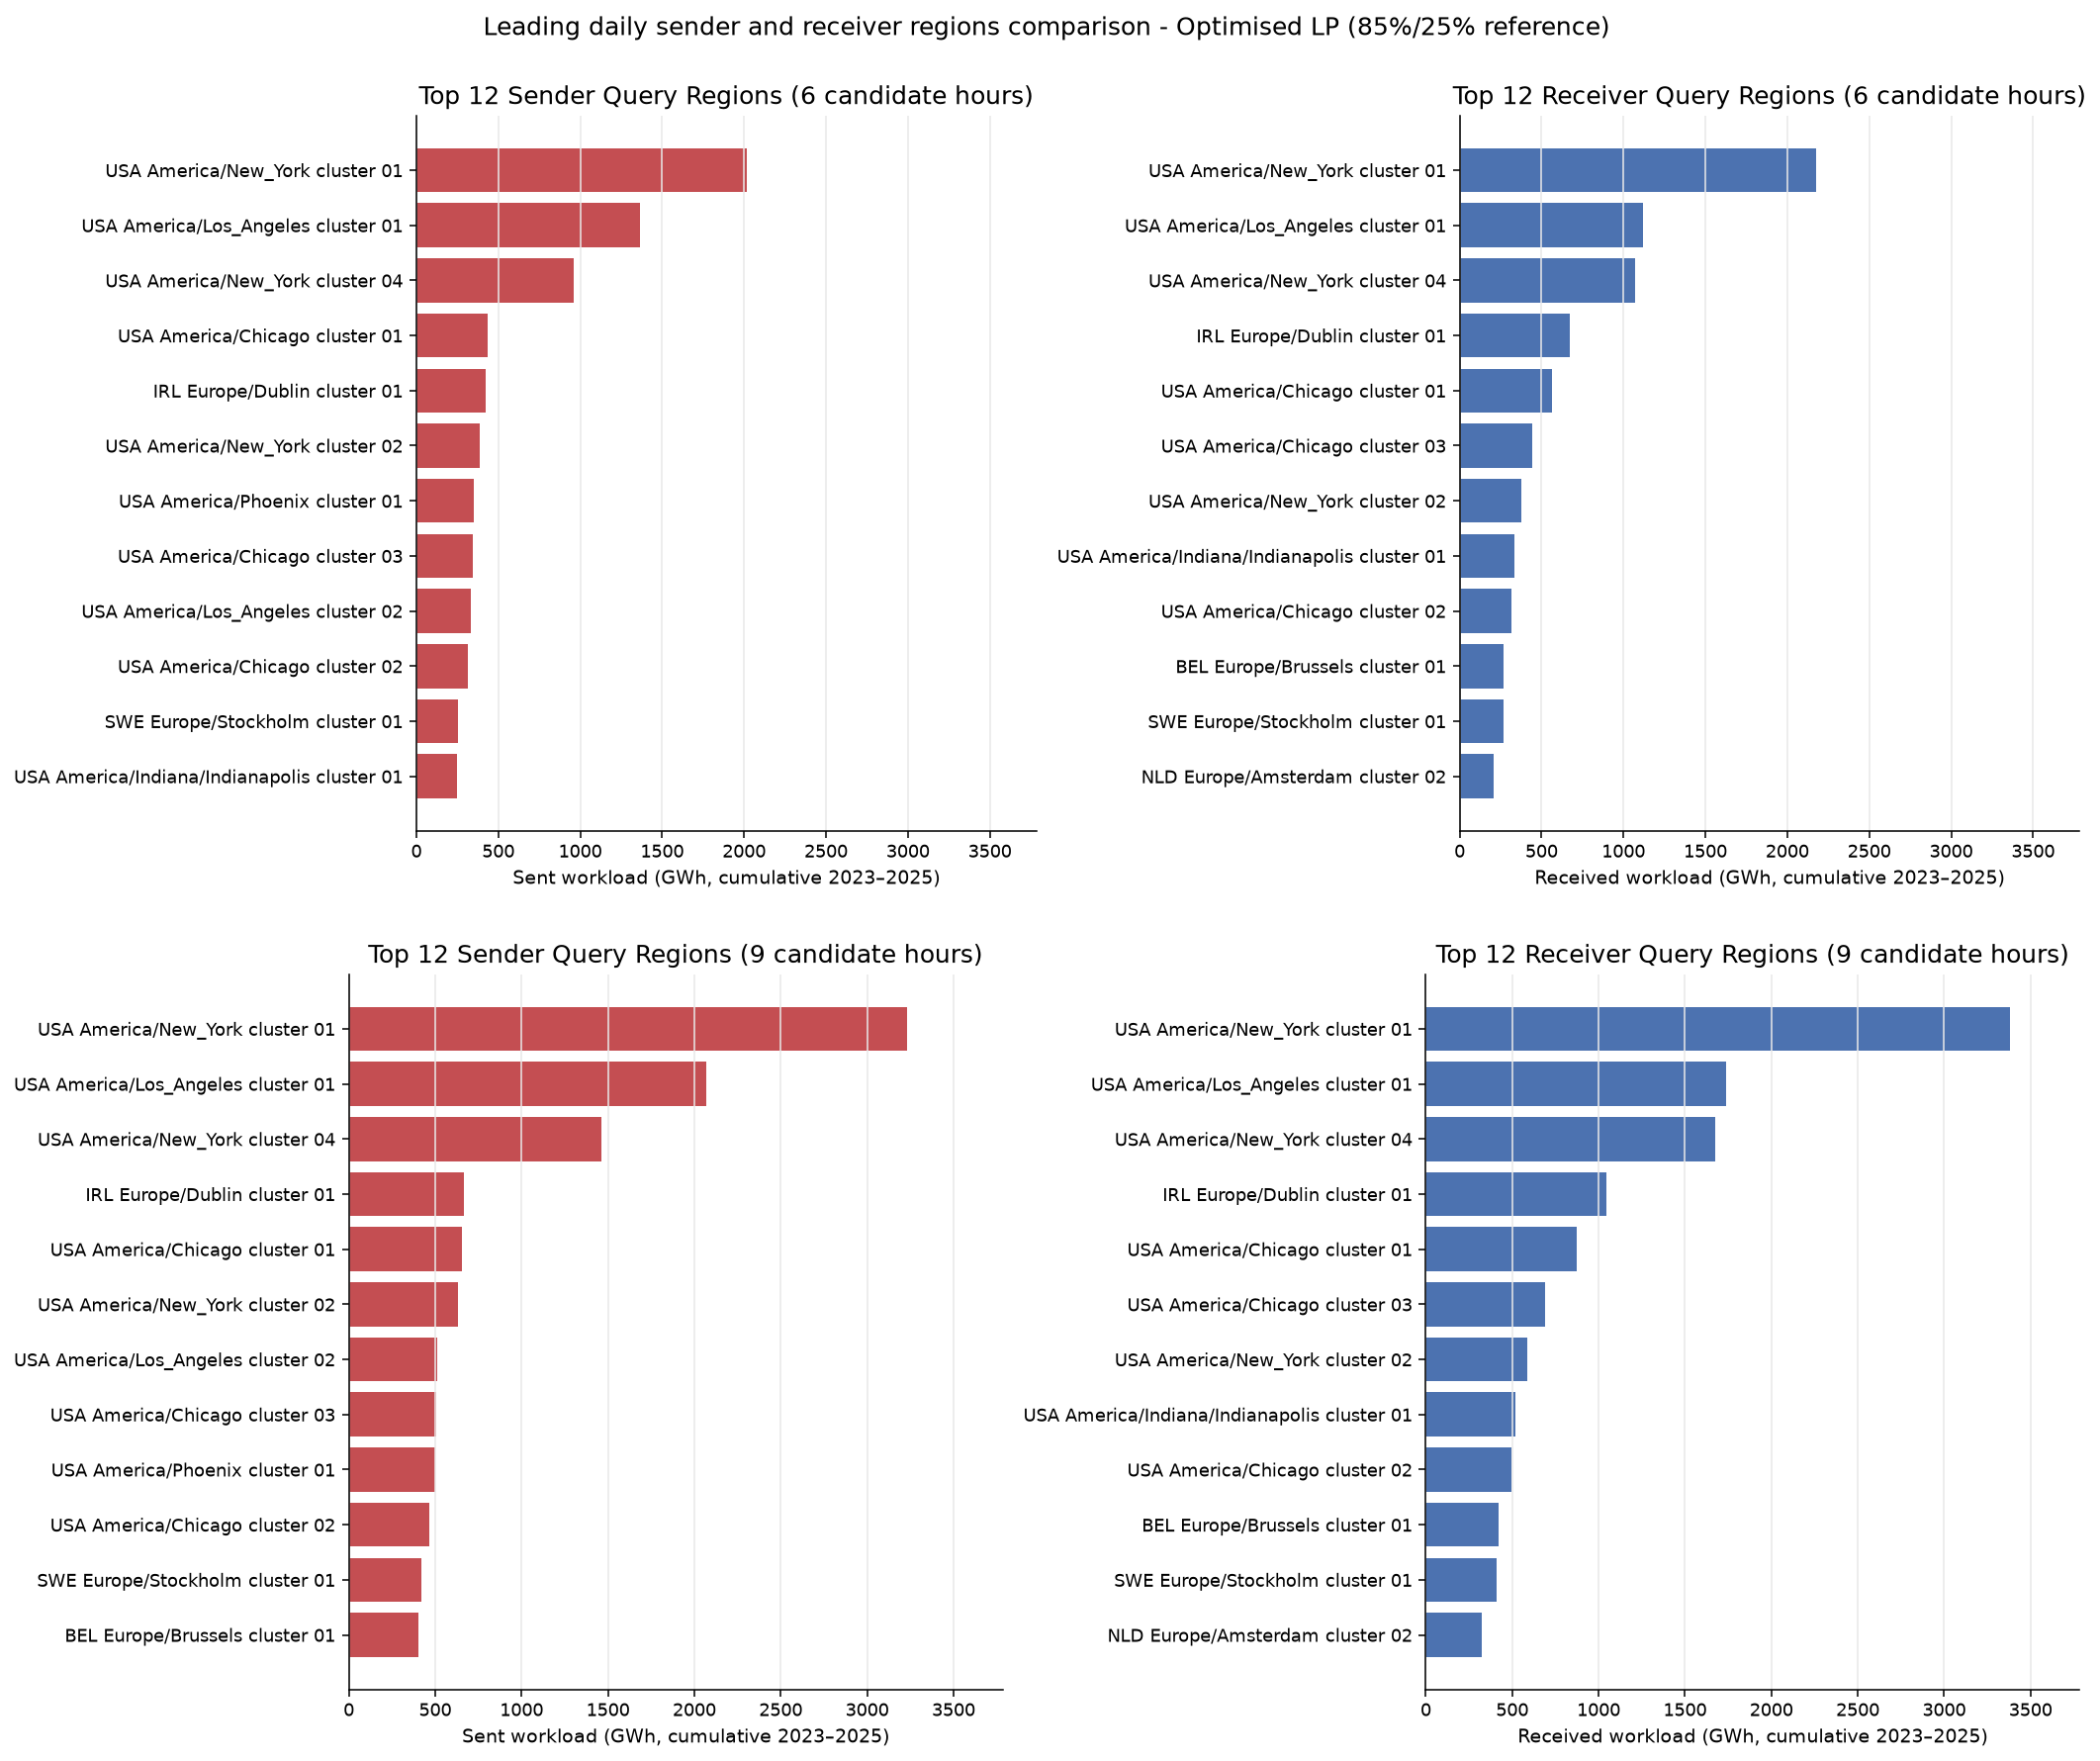

In [34]:
fig = plt.figure(figsize=(15, 12.6), layout="constrained")
panels = fig.subfigures(2, 1, hspace=0.05)

fig.suptitle("Leading daily sender and receiver regions comparison - Optimised LP (85%/25% reference)\n", fontsize=13)

for hours, panel in zip(CANDIDATE_HOURS, panels):
    axes = panel.subplots(1, 2)
    sender, receiver = region_summaries[(hours, "optimised_lp")]
    for ax, data, side, label in zip(axes, (sender, receiver), ("sender", "receiver"), ("Sent", "Received")):
        ax.barh(data[f"{side}_renewable_query_region"][::-1], data["shifted_gwh"][::-1], color=COLORS["send" if side == "sender" else "receive"])
        ax.set(title=f"Top 12 {side.title()} Query Regions ({hours} candidate hours)", xlabel=f"{label} workload (GWh, cumulative 2023–2025)", xlim=region_xlim)
        ax.grid(True, axis="x", color="#e8e8e8")

save_figure(fig, "08c_top_sender_receiver_regions", "optimised")

## 9 — Historical weather comparisons

Sum daily network shifted energy for current plus planned locations, retaining recorded zero-transfer days. Calculate annual totals for each allocation method, candidate-hour setting and weather year.

In [35]:
daily_shift["utc_date"] = pd.to_datetime(daily_shift["utc_date"]).dt.strftime("%Y-%m-%d")
network_daily = daily_shift.loc[daily_shift["model_layer"].eq("current_plus_future")].groupby(
    ["candidate_hours", "allocation_method", "weather_year", "utc_date"], as_index=False)["shifted_mwh"].sum()
network_daily["shifted_gwh_day"] = network_daily["shifted_mwh"] / 1000

weather_annual = network_daily.groupby(["candidate_hours", "allocation_method", "weather_year"])["shifted_gwh_day"].sum()

display(network_daily.groupby(["candidate_hours", "allocation_method", "weather_year"]).agg(
    network_days=("utc_date", "nunique"), zero_transfer_days=("shifted_mwh", lambda values: values.eq(0).sum())))

network_days  \
candidate_hours allocation_method weather_year                 
6               greedy            2023                   365   
                                  2024                   366   
                                  2025                   365   
                optimised_lp      2023                   365   
                                  2024                   366   
                                  2025                   365   
9               greedy            2023                   365   
                                  2024                   366   
                                  2025                   365   
                optimised_lp      2023                   365   
                                  2024                   366   
                                  2025                   365   

                                                zero_transfer_days  
candidate_hours allocation_method weather_year                      
6               greedy            2023                           0  
                                  2024                           0  
                                  2025                           0  
                optimised_lp      2023                           0  
                                  2024                           0  
                                  2025                           0  
9               greedy            2023                           0  
                                  2024                           0  
                                  2025                           0  
                optimised_lp      2023                           0  
                                  2024                           0  
                                  2025                           0

### Annual historical weather totals

Compare the three annual network totals for daily shifting at the reference workload assumptions. Calculate their arithmetic mean, minimum, maximum and relative range for each method and candidate-hour setting, then export the unrounded table.


In [36]:
weather_comparison = weather_annual.unstack("weather_year").reindex(
    pd.MultiIndex.from_product([CANDIDATE_HOURS, ALLOCATION_METHODS], names=["candidate_hours", "allocation_method"]))
weather_comparison = weather_comparison.reindex(columns=weather_years).rename(columns={year: f"shifted_gwh_{year}" for year in weather_years})
annual_columns = [f"shifted_gwh_{year}" for year in weather_years]
weather_comparison["mean_annual_shifted_gwh"] = weather_comparison[annual_columns].mean(axis=1)
weather_comparison["minimum_annual_shifted_gwh"] = weather_comparison[annual_columns].min(axis=1)
weather_comparison["maximum_annual_shifted_gwh"] = weather_comparison[annual_columns].max(axis=1)
weather_comparison["relative_range_percent"] = 100 * (weather_comparison["maximum_annual_shifted_gwh"] - weather_comparison["minimum_annual_shifted_gwh"]).div(
    weather_comparison["mean_annual_shifted_gwh"].where(weather_comparison["mean_annual_shifted_gwh"].ne(0)))
weather_comparison = weather_comparison.reset_index().rename_axis(columns=None)
weather_comparison.to_csv(WEATHER_COMPARISON_PATH, index=False)

display(weather_comparison.rename(columns={"candidate_hours": "Candidate hours", "allocation_method": "Method",
    **{f"shifted_gwh_{year}": f"{year} (GWh)" for year in weather_years},
    "mean_annual_shifted_gwh": "Mean (GWh/year)", "minimum_annual_shifted_gwh": "Minimum (GWh/year)",
    "maximum_annual_shifted_gwh": "Maximum (GWh/year)", "relative_range_percent": "Range / mean (%)"})
    .replace({"Method": {"greedy": "Greedy", "optimised_lp": "Optimised LP"}})
    .style.hide(axis="index").format(precision=3, na_rep="Undefined"))

Candidate hours,Method,2023 (GWh),2024 (GWh),2025 (GWh),Mean (GWh/year),Minimum (GWh/year),Maximum (GWh/year),Range / mean (%)
6,Greedy,4181.793,4186.140,4161.736,4176.556,4161.736,4186.140,0.584
6,Optimised LP,4182.986,4188.051,4163.467,4178.168,4163.467,4188.051,0.588
9,Greedy,6497.457,6505.118,6462.308,6488.294,6462.308,6505.118,0.660
9,Optimised LP,6502.554,6513.712,6469.715,6495.327,6469.715,6513.712,0.677


### Calendar timing of daily shifting

Overlay the daily LP totals for 2023–2025 on a common month-and-day axis without smoothing. Retain 29 February only for 2024 and annotate each candidate-hour panel with its annual range relative to the annual mean. The comparison describes variation across the supplied historical weather cases.


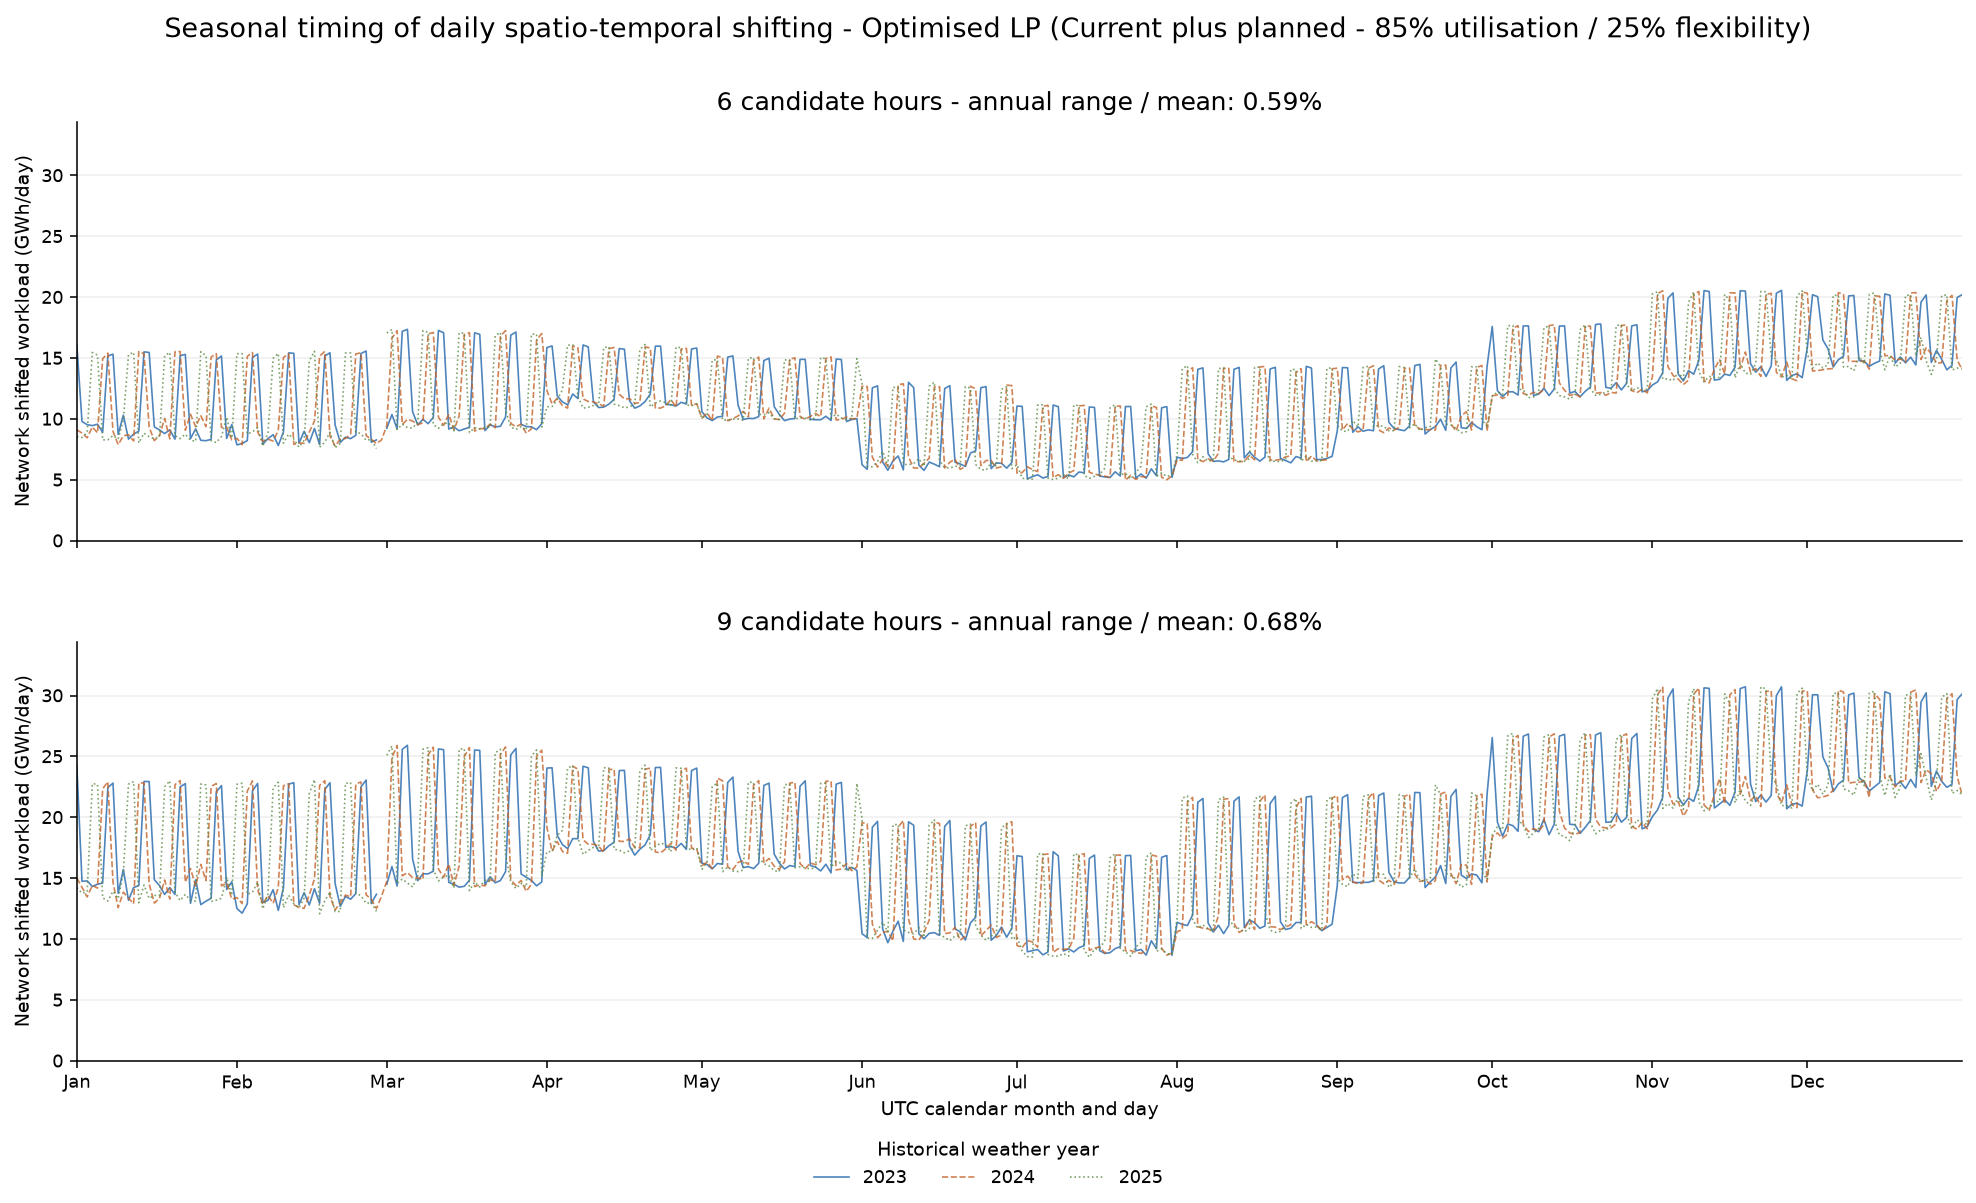

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8.5), sharex=True, sharey=True, layout="constrained")
fig.get_layout_engine().set(hspace=0.10)
season_calendar = pd.date_range("2000-01-01", "2000-12-31")

for ax, hours in zip(axes, CANDIDATE_HOURS):
    selected_daily = network_daily.loc[network_daily["candidate_hours"].eq(hours)
        & network_daily["allocation_method"].eq("optimised_lp")]
    for year, colour, style in zip(weather_years, ("#2166ac", "#c46328", "#5b8b45"), ("-", "--", ":")):
        values = selected_daily.loc[selected_daily["weather_year"].eq(year)].copy()
        values["calendar_day"] = pd.to_datetime("2000-" + pd.to_datetime(values["utc_date"]).dt.strftime("%m-%d"))
        series = values.set_index("calendar_day")["shifted_gwh_day"].reindex(season_calendar)
        ax.plot(series.index, series, linewidth=0.85, alpha=0.8, color=colour, linestyle=style, label=str(year))
    annual_values = weather_annual.loc[(hours, "optimised_lp")]
    relative_range = 100 * (annual_values.max() - annual_values.min()) / annual_values.mean()
    ax.set(title=f"{hours} candidate hours - annual range / mean: {relative_range:.2f}%",
        ylabel="Network shifted workload (GWh/day)", ylim=(0, upper_axis(network_daily["shifted_gwh_day"])))
    ax.grid(axis="y", alpha=0.2)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[-1].set(xlim=(season_calendar[0], season_calendar[-1]), xlabel="UTC calendar month and day")
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False, title="Historical weather year")
fig.suptitle("Seasonal timing of daily spatio-temporal shifting - Optimised LP (Current plus planned - 85% utilisation / 25% flexibility)\n", fontsize=14)

save_figure(fig, "09_daily_seasonal_structure", "main")